# Trabajo Fin de Máster


**Proyecto:** Modelo de predicción de riesgo de lesión o exacerbación de enfermedades crónicas y mentales por carga de actividad física registrada en relojes inteligentes

**Autora:** Irina Calvo Carvajal

**Tutores:** Carlos Ortega y Santiago Mota

**Institución:** Universidad Computense de Madrid — NTIC Máster

**Fecha:** Septiembre, 2026


## Librerías

In [894]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
from pathlib import Path
import sklearn
import svy
import polars as pl
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
import xgboost as XGBoost

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.inspection import permutation_importance

random_seed = 42

warnings.filterwarnings("ignore")

## Módulo: 01 - EDA

### Carga de datos

In [895]:
path = "data/raw/NHIS/adult24csv/adult24.csv"

base = Path.cwd() 
path = base.parent / path
# print(f"Data file path: {path}")

df_raw = pd.read_csv(path)

### Análisis de datos

In [896]:
print(f"Dimensiones: {df_raw.shape}")

Dimensiones: (32629, 630)


In [897]:
print(f"Total de observaciones: {len(df_raw)}")

Total de observaciones: 32629


In [898]:
print(f"Columnas: {len(df_raw.columns)}\n" + "\n".join(df_raw.columns.tolist()))

Columnas: 630
RATCAT_A
INCTCFLG_A
IMPINCFLG_A
PPSU
PSTRAT
WLKLEISTC_A
WLKTRANTC_A
HISPALLP_A
RACEALLP_A
ANYDIFF_A
DISAB3_A
NUMBRN1TC_A
K6SPD_A
SCHDYMSSTC_A
AFNOW
REPWRKDYTC_A
YRSINUS_A
CITZNSTP_A
PRTNREDUCP_A
SPOUSEDUCP_A
LEGMSTAT_A
MARSTAT_A
SASPPRACE_A
SASPPHISP_A
PRTNRAGETC_A
SPOUSAGETC_A
PRTNRWKFT_A
PRTNRWRK_A
SPOUSWKFT_A
SPOUSWRK_A
SPOUSESEX_A
PRTNRSEX_A
INJWRKDYTC_A
NUMINJTC_A
SHINGYEARP_A
PROXYREL2_A
PROXYFLAG_A
HHRESPSA_FLG
PCNTADWFP1_A
PCNTADWKP1_A
FDSCAT4_A
FDSCAT3_A
EMPDYSMSS3_A
EMPLSTWOR1_A
EMPWRKFT1_A
EMPWRKLSW1_A
EMPWKHRS3_A
EMDOCCUPN2_A
EMDOCCUPN1_A
EMDINDSTN2_A
EMDINDSTN1_A
DIBAGETC_A
DIFYRSTC1_A
SMKQTNP_A
SMKQTY_A
SMKECIGST_A
SMKCIGST_A
BMICATD_A
BMICAT_A
WEIGHTLBTC_A
HEIGHTTC_A
DRKHVY12M_A
DRKSTAT_A
DRK12MYR_A
DRK12MWK_A
RETAILHC12MTC_A
URGCC12MTC_A
EMERG12MTC_A
CVDSMELCHG_A
PA18_05R_A
PA18_02R_A
MODFREQW_A
MODNR_A
MODTPR_A
MODLNR_A
MODLTPR_A
MODMIN_A
VIGNR_A
VIGTPR_A
VIGLNR_A
VIGLTPR_A
VIGFREQW_A
VIGMIN_A
STRTPR_A
STRNR_A
STRFREQW_A
PCNT18UPTC
PCNTLT18TC
LANGSPECR_A


In [899]:
df_raw.describe()

,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,HYPDIF_A,HYPEV_A,LSATIS4_A,PHSTAT_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,WTFA_A,POVRATTC_A
count,32629.000000,32629.000000,32629.000000,32629.000000,32629.000000,18811.000000,5158.000000,32629.000000,32629.000000,32629.000000,...,12263.000000,32629.000000,32629.000000,32629.000000,32629.0,32629.000000,32629.0,32629.0,32629.000000,32629.000000
mean,9.686996,0.031352,0.362162,31.483190,125.777192,38.649141,28.748934,2.188268,1.730424,1.498422,...,1.158526,1.633118,1.626529,2.482607,1.0,6.467222,10.0,1.0,7957.765652,4.124075
std,4.025306,0.174271,0.705139,29.277681,15.641568,51.901138,64.959799,0.976499,1.727185,0.501719,...,0.560325,0.541155,0.689749,1.061539,0.0,3.414323,0.0,0.0,5776.533149,2.966154
min,1.000000,0.000000,0.000000,1.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,10.0,1.0,265.078000,0.000000
25%,7.000000,0.000000,0.000000,8.000000,112.000000,20.000000,10.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,2.000000,1.0,4.000000,10.0,1.0,3839.683000,1.840000
50%,10.000000,0.000000,0.000000,24.000000,125.000000,30.000000,20.000000,2.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,1.0,6.000000,10.0,1.0,6507.268000,3.350000
75%,14.000000,0.000000,0.000000,48.000000,140.000000,45.000000,30.000000,2.000000,2.000000,2.000000,...,1.000000,2.000000,2.000000,3.000000,1.0,9.000000,10.0,1.0,10285.669000,5.670000
max,14.000000,1.000000,2.000000,153.000000,151.000000,999.000000,999.000000,7.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,1.0,12.000000,10.0,1.0,38138.226000,11.000000


In [900]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Columns: 630 entries, RATCAT_A to POVRATTC_A
dtypes: float64(401), int64(227), object(2)
memory usage: 156.8+ MB


In [901]:
df_raw.head(3)

,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,AVGNUMCIG_A,WTFA_A,HHX,POVRATTC_A
0,9,0,2,2,122,NaN,NaN,2,1,2,...,1,1,1,1,10,1,30,5780.565,H067658,2.82
1,8,0,0,2,122,20.0,NaN,2,1,2,...,2,2,1,1,10,1,20,3994.244,H076577,2.01
2,7,0,0,2,122,30.0,NaN,2,1,1,...,1,2,1,1,10,1,20,6636.755,H019335,1.90


---
#### Columnas estructurales de encuesta

"To appropriately analyze NHIS data, it is necessary to utilize weights and variance estimation variables. This is 
because the NHIS uses a complex sample design involving stratification and clustering designed to represent the 
civilian noninstitutionalized population of the United States and not all sampled respondents respond. If data 
are not weighted, severely biased estimates may result, such as producing estimates that are not representative 
of the NHIS target population. If the correct variance estimation variables are not used, then estimates of 
precision, such as standard errors, will likely be smaller than they should be. This will make the data appear to 
be more precise and will result in more statistically significant differences between estimates and in other 
analyses that are subject to excessive Type I error (rejection of a true null hypothesis).    
Applying Sample Weight and Variance Estimation Variables in Analysis 
 
Several software packages are available for analyzing complex samples. Below are examples of computer code 
for specifying sample weight and variance estimation variables for standard error calculation code of means, 
percentages and totals with the NHIS data using SUDAAN, Stata, SPSS, SAS, and R software packages for 
illustrative purposes. The examples below use the Sample Adult sampling weight (WTFA_A) or for Sample Child 
analysis, use the Sample Child sampling weight (WTFA_C).  The limited public release design information requires a mathematical simplification that the PSUs be treated as 
if they were sampled with replacement (WR). The simplified design structure can be specified for the file with 
the following statements in selected software packages."


* WTFA_A: Sample Weight. Ajusta por probabilidad de selección, no respuesta y calibración poblacional para representar a la población de EE.UU.
* PSTRAT: Pseudo estrato. Captura la estratificación geográfica del diseño muestral.
* PPSU: Unidad primaria de muestreo. Identifica la agrupación por conglomerados (clusters).

Para aplicar esto en Python, hay que utilizar alguna librería que lo permita para operaciones en EDA como statsmodels o samplics.
En muchos casos, scikit-learn nos deja usar el sample_weight también.

---

In [902]:
sample_vars = [
    'WTFA_A', # sample weight
    'PSTRAT', # pseudostato
    'PPSU' # unidad de muestreo primaria
]

In [903]:
# Variables to explore

physical_activity_vars = [
    "MODFREQW_A", # moderate activity frequency per week
    'MODMIN_A', # moderate activity minutes per time
    "MODNR_A", # moderate activity number of times per week
    'MODTPR_A', # moderate activity minutes per time (moderate time period / unit)
    'MODLNR_A', # moderate activity number of times per week (light/moderate)
    'MODLTPR_A', # moderate activity minutes per time (light/moderate time period / unit)
    "VIGFREQW_A", # vigorous activity frequency per week
    'VIGMIN_A', # vigorous activity minutes per time
    'VIGNR_A', # vigorous activity number of times per week
    'VIGTPR_A', # vigorous activity minutes per time (vigorous time period / unit)
    'VIGLNR_A', # vigorous activity number of times per week (light/vigorous)
    'VIGLTPR_A', # vigorous activity minutes per time (light/vigorous time period / unit)
    'STRFREQW_A', # strength training frequency per week
    'STRNR_A', # strength training number of times per week
]

In [904]:
df_temp = df_raw.copy()


df_active = df_temp[(df_temp['MODMIN_A'] > 0) | (df_temp['VIGMIN_A'] > 0)]
df_active.shape

(23358, 630)

In [905]:
psych_distress_vars = [
    "ANXEV_A", # Ansiedad
    "DEPEV_A", # Depresión
    "SAD_A", # Variables Kessler
    "NERVOUS_A", 
    "RESTLESS_A", 
    "HOPELESS_A", 
    "EFFORT_A", 
    "WORTHLESS_A"
]

In [906]:
respiratory_vars = [
    'ASEV_A', # Asma
    'ASAT12M_A', # Asma diagnosticada en los últimos 12 meses
    'COPDEV_A', # EPOC (Enfermedad Pulmonar Obstructiva Crónica), enfisema o bronquitis
]

In [907]:
metabolic_vars = [
    'DIBEV_A', # Diabetes
    'PREDIB_A', # Prediabetes
    'HYPEV_A', # Hipertensión
    'CHLEV_A' # Colesterol alto
]

cardiovasc_vars = [
    'CHDEV_A', # Enfermedad coronaria
    'ANGEV_A', # Angina de pecho
    'MIEV_A', # Infarto de miocardio (Ataque al corazón)
    'STREV_A' # Ictus / Accidente cerebrovascular (Stroke)
]


In [908]:
basic_vars = [
    'AGEP_A', # Age
    'SEX_A', # Sex
    'BMICAT_A', # BMI category
    'HEIGHTTC_A', # Height (total centimeters)
]


In [909]:
fatigue_vars = [
    'CFSEV_A', # Síndrome de Fatiga Crónica o Encefalomielitis Miálgica (ME/CFS)
    'FGEFRQTRD_A', # Frecuencia de cansancio last 3m
    'SLPHOURS_A' # Horas de sueño por noche
]

auto_infl_vars = [
    'ARTHEV_A', # Artritis, artritis reumatoide, gota, lupus o fibromialgia
    'CROHNSEV_A', # Enfermedad de Crohn
    'ULCCOLEV_A', # Colitis Ulcerosa
    'PSOREV_A' # Psoriasis
]

In [910]:
injury_vars = [
    "ANYINJURY_A", # Tuvo alguna lesión
    "REPSTRAIN_A", # Lesiones por esfuerzo repetitivo /3m
    "REPLIMIT_A", # RSI limitó actividades por >=24h
    "REPSAWDOC_A", # evaluado por médico por RSI
    "INJSPORTS_A", # lesión fue por deporte
    "INJLIMIT_A", # limitó actividades por >= 24h
    "INJSAWDOC_A", # evaluado por médico
    "INJER_A", # atendido en emergencias por lesion
    "INJHOSP_A", # atendido en hospital por lesion
    "INJBONES_A", # hueso roto/ severidad
    "INJSTITCH_A", # puntadas por lesión/ severidad
    "TBILCDCMG_A", # Si tras un golpe en la cabeza quedó aturdido, perdió el conocimiento o tuvo pérdida de memoria /12m
    "TBISPORT_A", # Si evento TBI sucedió entrenando/compitiendo
    "TBIHLSBMC_A", # Golpe con dolor de cabeza/sensibilidad a luz-ruido/problemas de equilibrio/cambios de ánimo /12m
    "TBILEAGUE_A", # en evento equipo/liga
    "TBIEVAL_A" # evaluado por médico
]

In [911]:
selected_vars = sample_vars + physical_activity_vars + psych_distress_vars + respiratory_vars + metabolic_vars + cardiovasc_vars + basic_vars + fatigue_vars + auto_infl_vars + injury_vars

df_selected = df_raw[selected_vars].copy()

print(f"Possible target variables:\n")
for col in selected_vars:
    print(f"{col}: {df_selected[col].value_counts()}")

Possible target variables:

WTFA_A: WTFA_A
6688.172     4
31466.980    3
3752.308     3
34764.502    3
3677.464     3
            ..
5172.310     1
6408.530     1
30575.820    1
6025.736     1
2800.466     1
Name: count, Length: 32124, dtype: int64
PSTRAT: PSTRAT
109    1128
144    1095
151    1045
149     978
100     882
113     871
119     857
122     827
114     825
108     793
107     772
101     765
148     758
129     731
134     713
147     669
146     658
140     655
137     644
117     641
143     634
118     631
110     622
126     607
131     596
132     582
121     575
130     574
141     570
124     567
135     567
106     561
133     559
150     556
104     547
136     539
102     531
105     527
138     527
120     525
115     504
123     504
127     481
111     475
145     468
142     431
103     418
116     399
125     363
139     360
128     275
112     247
Name: count, dtype: int64
PPSU: PPSU
1      1921
2      1543
3      1226
4       949
10      883
       ... 
118

In [912]:
print(f"Selected Dataset Shape: {df_selected.shape}")

Selected Dataset Shape: (32629, 63)


In [913]:
print(f"Columns: {df_selected.columns.tolist()}")

Columns: ['WTFA_A', 'PSTRAT', 'PPSU', 'MODFREQW_A', 'MODMIN_A', 'MODNR_A', 'MODTPR_A', 'MODLNR_A', 'MODLTPR_A', 'VIGFREQW_A', 'VIGMIN_A', 'VIGNR_A', 'VIGTPR_A', 'VIGLNR_A', 'VIGLTPR_A', 'STRFREQW_A', 'STRNR_A', 'ANXEV_A', 'DEPEV_A', 'SAD_A', 'NERVOUS_A', 'RESTLESS_A', 'HOPELESS_A', 'EFFORT_A', 'WORTHLESS_A', 'ASEV_A', 'ASAT12M_A', 'COPDEV_A', 'DIBEV_A', 'PREDIB_A', 'HYPEV_A', 'CHLEV_A', 'CHDEV_A', 'ANGEV_A', 'MIEV_A', 'STREV_A', 'AGEP_A', 'SEX_A', 'BMICAT_A', 'HEIGHTTC_A', 'CFSEV_A', 'FGEFRQTRD_A', 'SLPHOURS_A', 'ARTHEV_A', 'CROHNSEV_A', 'ULCCOLEV_A', 'PSOREV_A', 'ANYINJURY_A', 'REPSTRAIN_A', 'REPLIMIT_A', 'REPSAWDOC_A', 'INJSPORTS_A', 'INJLIMIT_A', 'INJSAWDOC_A', 'INJER_A', 'INJHOSP_A', 'INJBONES_A', 'INJSTITCH_A', 'TBILCDCMG_A', 'TBISPORT_A', 'TBIHLSBMC_A', 'TBILEAGUE_A', 'TBIEVAL_A']


In [914]:
df_selected.head(3)

,WTFA_A,PSTRAT,PPSU,MODFREQW_A,MODMIN_A,MODNR_A,MODTPR_A,MODLNR_A,MODLTPR_A,VIGFREQW_A,...,INJSAWDOC_A,INJER_A,INJHOSP_A,INJBONES_A,INJSTITCH_A,TBILCDCMG_A,TBISPORT_A,TBIHLSBMC_A,TBILEAGUE_A,TBIEVAL_A
0,5780.565,122,2,6,30.0,6,2,30.0,1.0,94,...,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN
1,3994.244,122,2,94,NaN,0,0,NaN,NaN,94,...,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN
2,6636.755,122,2,94,NaN,0,0,NaN,NaN,94,...,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN


---
#### Codificación CDC para respuestas

1 = Sí (Tiene la condición)

2 = No (No la tiene)

7 = Refused (Se negó a contestar)

9 = Don't Know (No sabe)

* algunas respuestas incluyen 9s a la izquierda para llenar el espacio

---

#### Clasificación de variables

In [915]:
# Numéricas y categóricas
numeric_vars = df_selected.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df_selected.select_dtypes(include=['object']).columns.tolist()

print(f"Sample vars: {len(sample_vars)} \nNumeric vars: {len(numeric_vars)} \nCategorical vars: {len(categorical_vars)}")

for var in numeric_vars:
    print(f"{var}: {df_selected[var].value_counts()}")


Sample vars: 3 
Numeric vars: 63 
Categorical vars: 0
WTFA_A: WTFA_A
6688.172     4
31466.980    3
3752.308     3
34764.502    3
3677.464     3
            ..
5172.310     1
6408.530     1
30575.820    1
6025.736     1
2800.466     1
Name: count, Length: 32124, dtype: int64
PSTRAT: PSTRAT
109    1128
144    1095
151    1045
149     978
100     882
113     871
119     857
122     827
114     825
108     793
107     772
101     765
148     758
129     731
134     713
147     669
146     658
140     655
137     644
117     641
143     634
118     631
110     622
126     607
131     596
132     582
121     575
130     574
141     570
124     567
135     567
106     561
133     559
150     556
104     547
136     539
102     531
105     527
138     527
120     525
115     504
123     504
127     481
111     475
145     468
142     431
103     418
116     399
125     363
139     360
128     275
112     247
Name: count, dtype: int64
PPSU: PPSU
1      1921
2      1543
3      1226
4       949
1

Por la naturaleza de las variables utilizadas en NHIS, las variables categóricas están siendo interpretadas como numéricas, por lo que se deben separar manualmente

In [916]:
numeric_vars = [
    'MODFREQW_A', # int
    'MODMIN_A', # float
    'MODNR_A', # int
    'MODLNR_A', # float
    'VIGFREQW_A', # int
    'VIGMIN_A', # int -> float
    'VIGNR_A', # int
    'VIGLNR_A', # float -> int
    'STRFREQW_A', # int
    'STRNR_A', # int
    'AGEP_A', # int
    'HEIGHTTC_A', # int
    'SLPHOURS_A' #int
]

categorical_vars = [col for col in df_selected.columns if col not in numeric_vars and col not in sample_vars]

# print(f"Sample vars: {len(sample_vars)} \nNumeric vars: {len(numeric_vars)} \nCategorical vars: {len(categorical_vars)}")

print(f"Sample vars: {len(sample_vars)} ------------------------")
print(f"Numeric vars: {len(numeric_vars)} ------------------------")
for var in numeric_vars:
    print(f"{var}: {df_selected[var].value_counts()}")
print(f"Categorical vars: {len(categorical_vars)} ------------------------")
for var in categorical_vars:
    print(f"{var}: {df_selected[var].value_counts()}")


Sample vars: 3 ------------------------
Numeric vars: 13 ------------------------
MODFREQW_A: MODFREQW_A
94    8786
7     5593
3     4173
2     3471
1     2650
5     2195
4     2075
0     1192
98     801
6      544
14     436
95     170
21     155
96     132
99      81
28      72
97      32
10      16
12      12
15       8
20       6
11       5
23       4
13       4
9        3
17       3
22       2
8        2
27       2
25       2
16       1
18       1
Name: count, dtype: int64
MODMIN_A: MODMIN_A
60.0     6675
30.0     5655
45.0     2409
120.0    1683
20.0     1323
         ... 
58.0        1
26.0        1
46.0        1
68.0        1
48.0        1
Name: count, Length: 75, dtype: int64
MODNR_A: MODNR_A
0       8786
1       6365
3       4497
2       4325
5       2274
4       2258
7       2042
9998     801
6        574
9995     170
9996     132
9999      81
10        59
15        33
9997      32
12        27
30        26
8         22
20        20
14        12
13         7
365        7
9  

#### Duplicados

In [917]:
print(f"Filas duplicadas: {df_selected.duplicated().sum()}")

Filas duplicadas: 0


Columnas con valores nulos:
* MODMIN_A
* MODLNR_A
* MODLTPR_A
* VIGMIN_A
* VIGLNR_A
* VIGLTPR_A
* ASAT12M_A
* REPSAWDOC_A
* INJSPORTS_A
* INJSAWDOC_A
* INJER_A
* INJHOSP_A
* INJBONES_A
* INJSTITCH_A
* TBISPORT_A
* TBIHLSBMC_A
* TBILEAGUE_A
* TBIEVAL_A


In [918]:
print(df_selected.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Data columns (total 63 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   WTFA_A       32629 non-null  float64
 1   PSTRAT       32629 non-null  int64  
 2   PPSU         32629 non-null  int64  
 3   MODFREQW_A   32629 non-null  int64  
 4   MODMIN_A     22797 non-null  float64
 5   MODNR_A      32629 non-null  int64  
 6   MODTPR_A     32629 non-null  int64  
 7   MODLNR_A     22797 non-null  float64
 8   MODLTPR_A    22797 non-null  float64
 9   VIGFREQW_A   32629 non-null  int64  
 10  VIGMIN_A     11312 non-null  float64
 11  VIGNR_A      32629 non-null  int64  
 12  VIGTPR_A     32629 non-null  int64  
 13  VIGLNR_A     11312 non-null  float64
 14  VIGLTPR_A    11312 non-null  float64
 15  STRFREQW_A   32629 non-null  int64  
 16  STRNR_A      32629 non-null  int64  
 17  ANXEV_A      32629 non-null  int64  
 18  DEPEV_A      32629 non-null  int64  
 19  SAD_

#### Códigos especiales

*Nota metodológica: códigos 95/96 en variables de actividad física*

Los códigos 95/96 (y análogos 995/996, 9995/9996) en las variables de actividad 
física no corresponden al código "96 = Not available" documentado para altura/peso 
(HEIGHTTC_A), que es específico de esas variables por razones de confidencialidad. 
Basado en el patrón general de NHIS de usar códigos altos para "valor fuera de 
rango" (ej. año de vacuna <2006 recodificado a 9996, según srvydesc-508.pdf p.88) 
y en la documentación histórica de IPUMS sobre "Extreme value" para estas mismas 
preguntas de actividad física, se interpretan como valores de frecuencia 
extrema/top-coded, no sustantivos para el análisis, y se recodifican como NaN.

In [919]:
# special_codes = {
#     7: 'refused',
#     9: 'dont_know',
#     94: 'no_activity',
#     96: 'not_ascertained',
#     97: 'not_ascertained',
#     98: 'not_ascertained',
#     99: 'not_ascertained',
#     9995: 'not_ascertained',
#     9996: 'not_ascertained',
#     9997: 'not_ascertained',
#     9998: 'not_ascertained',
# } ??????


recode_nan = {
    # Actividad física
    'MODFREQW_A': [95, 97, 98, 99],
    'MODMIN_A': [996, 997, 998, 999],
    'MODNR_A': [9995, 9997, 9998, 9999],
    'MODTPR_A': [5, 7, 8, 9], # 6 significa que no puede hacer actividad, posible lesion/enfermedad
    'MODLNR_A': [995, 996, 997, 998, 999],
    'MODLTPR_A': [5, 6, 7, 8, 9],

    'VIGFREQW_A': [95, 97, 98, 99],
    'VIGMIN_A': [996, 997, 998, 999],
    'VIGNR_A': [9995, 9997, 9998, 9999],
    'VIGTPR_A': [5, 7, 8, 9], # 6 significa que no puede hacer actividad, posible lesion/enfermedad
    'VIGLNR_A': [995, 996, 997, 998, 999],
    'VIGLTPR_A': [5, 6, 7, 8, 9],

    'STRFREQW_A': [95, 97, 98, 99],
    'STRNR_A': [9995, 9997, 9998, 9999],

    # Kessler vars y enfermedades
    'SAD_A': [7, 8, 9],
    'NERVOUS_A': [7, 8, 9],
    'RESTLESS_A': [7, 8, 9],
    'HOPELESS_A': [7, 8, 9],
    'EFFORT_A': [7, 8, 9],
    'WORTHLESS_A': [7, 8, 9],
    'ASEV_A': [7, 8, 9],
    'ASAT12M_A': [7, 8, 9],
    'COPDEV_A': [7, 8, 9],
    'DIBEV_A': [7, 8, 9],
    'PREDIB_A': [7, 8, 9],
    'HYPEV_A': [7, 8, 9],
    'CHLEV_A': [7, 8, 9],
    'CHDEV_A': [7, 8, 9],
    'ANGEV_A': [7, 8, 9],
    'MIEV_A': [7, 8, 9],
    'STREV_A': [7, 8, 9],
    'ANXEV_A': [7, 8, 9],
    'DEPEV_A': [7, 8, 9],
    'ARTHEV_A': [7, 8, 9],
    'CROHNSEV_A': [7, 8, 9],
    'ULCCOLEV_A': [7, 8, 9],
    'PSOREV_A': [7, 8, 9],
    'CFSEV_A': [7, 8, 9],
    'ANYINJURY_A': [7, 8, 9],
    "REPSTRAIN_A":  [7, 8, 9],
    "REPLIMIT_A": [7, 8, 9], 
    "REPSAWDOC_A": [7, 8, 9],
    "INJSPORTS_A": [7, 8, 9],
    "INJLIMIT_A": [7, 8, 9],
    "INJSAWDOC_A": [7, 8, 9],
    "INJER_A": [7, 8, 9],
    "INJHOSP_A": [7, 8, 9],
    "INJBONES_A": [7, 8, 9],
    "INJSTITCH_A": [7, 8, 9],
    "TBILCDCMG_A": [7, 8, 9],
    "TBISPORT_A": [7, 8, 9],
    "TBIHLSBMC_A": [7, 8, 9],
    "TBILEAGUE_A": [7, 8, 9],
    "TBIEVAL_A": [7, 8, 9],

    # Demograficas
    'AGEP_A': [97, 98, 99], # -> 85 sigue siendo válido
    'SEX_A': [7, 8, 9],
    'HEIGHTTC_A': [96, 97, 98, 99],
    'BMICAT_A': [9],

    # Fatiga
    'FGEFRQTRD_A': [7, 8, 9],
    'SLPHOURS_A': [97, 98, 99]
}

recode_zero = {
    'MODFREQW_A': 94,
    'VIGFREQW_A': 94,
    'STRFREQW_A': 94
}

recode_incap = {
    'MODTPR_A':   6,
    'VIGTPR_A':   6,
    'MODFREQW_A': 96,
    'MODNR_A':    9996,
    'VIGFREQW_A': 96,
    'VIGNR_A':    9996,
    'STRFREQW_A': 96,
    'STRNR_A': 9996
}

In [920]:
def recode_special_codes(df: pd.DataFrame, dict_to_nan: dict, dict_to_zero: dict, dict_to_neg: dict) -> pd.DataFrame:
    """
    Recibe un DataFrame, un diccionario de codigos especiales a recodificar a cero y otro 
        diccionario a recodificar a NaN.
    Retorna una copia del DataFrame recibido, con valores recodificados a cero o NaNs de acuerdo a 
        los diccionarios recibidos.
    """
    df_recoded = df.copy()

    # Recodificar a NaNs
    for col, codes in dict_to_nan.items():
        if col not in df_recoded.columns:
            continue
        recoded = df_recoded[col].isin(codes).sum()
        df_recoded[col] = df_recoded[col].replace(codes, np.nan)
        if recoded > 0:
            print(f"{col}: {recoded} filas recodificadas a NaN.")

    # Recodificar a ceros
    for col, code in dict_to_zero.items():
        if col not in df_recoded.columns:
            continue
        recoded = (df_recoded[col] == code).sum()
        df_recoded[col] = df_recoded[col].replace(code, 0)
        if recoded > 0:
            print(f"{col}: {recoded} filas recodificadas de {code} a 0.")

    # Recodificar a -1 por incapacidad
    for col, code in dict_to_neg.items():
        if col not in df_recoded.columns:
            continue
        recoded = (df_recoded[col] == code).sum()
        df_recoded[col] = df_recoded[col].replace(code, -1)
        if recoded > 0:
            print(f"{col}: {recoded} filas recodificadas de {code} a -1.")

    return df_recoded

In [921]:
df_clean_special_codes = recode_special_codes(df_selected, recode_nan, recode_zero, recode_incap)

missing = df_clean_special_codes.isna().sum().sort_values(ascending=False)
print(missing)

MODFREQW_A: 1084 filas recodificadas a NaN.
MODMIN_A: 110 filas recodificadas a NaN.
MODNR_A: 1084 filas recodificadas a NaN.
MODTPR_A: 1084 filas recodificadas a NaN.
MODLNR_A: 110 filas recodificadas a NaN.
MODLTPR_A: 110 filas recodificadas a NaN.
VIGFREQW_A: 1003 filas recodificadas a NaN.
VIGMIN_A: 47 filas recodificadas a NaN.
VIGNR_A: 1003 filas recodificadas a NaN.
VIGTPR_A: 1003 filas recodificadas a NaN.
VIGLNR_A: 47 filas recodificadas a NaN.
VIGLTPR_A: 47 filas recodificadas a NaN.
STRFREQW_A: 961 filas recodificadas a NaN.
STRNR_A: 961 filas recodificadas a NaN.
SAD_A: 676 filas recodificadas a NaN.
NERVOUS_A: 696 filas recodificadas a NaN.
RESTLESS_A: 689 filas recodificadas a NaN.
HOPELESS_A: 700 filas recodificadas a NaN.
EFFORT_A: 731 filas recodificadas a NaN.
WORTHLESS_A: 719 filas recodificadas a NaN.
ASEV_A: 31 filas recodificadas a NaN.
ASAT12M_A: 7 filas recodificadas a NaN.
COPDEV_A: 40 filas recodificadas a NaN.
DIBEV_A: 29 filas recodificadas a NaN.
PREDIB_A: 

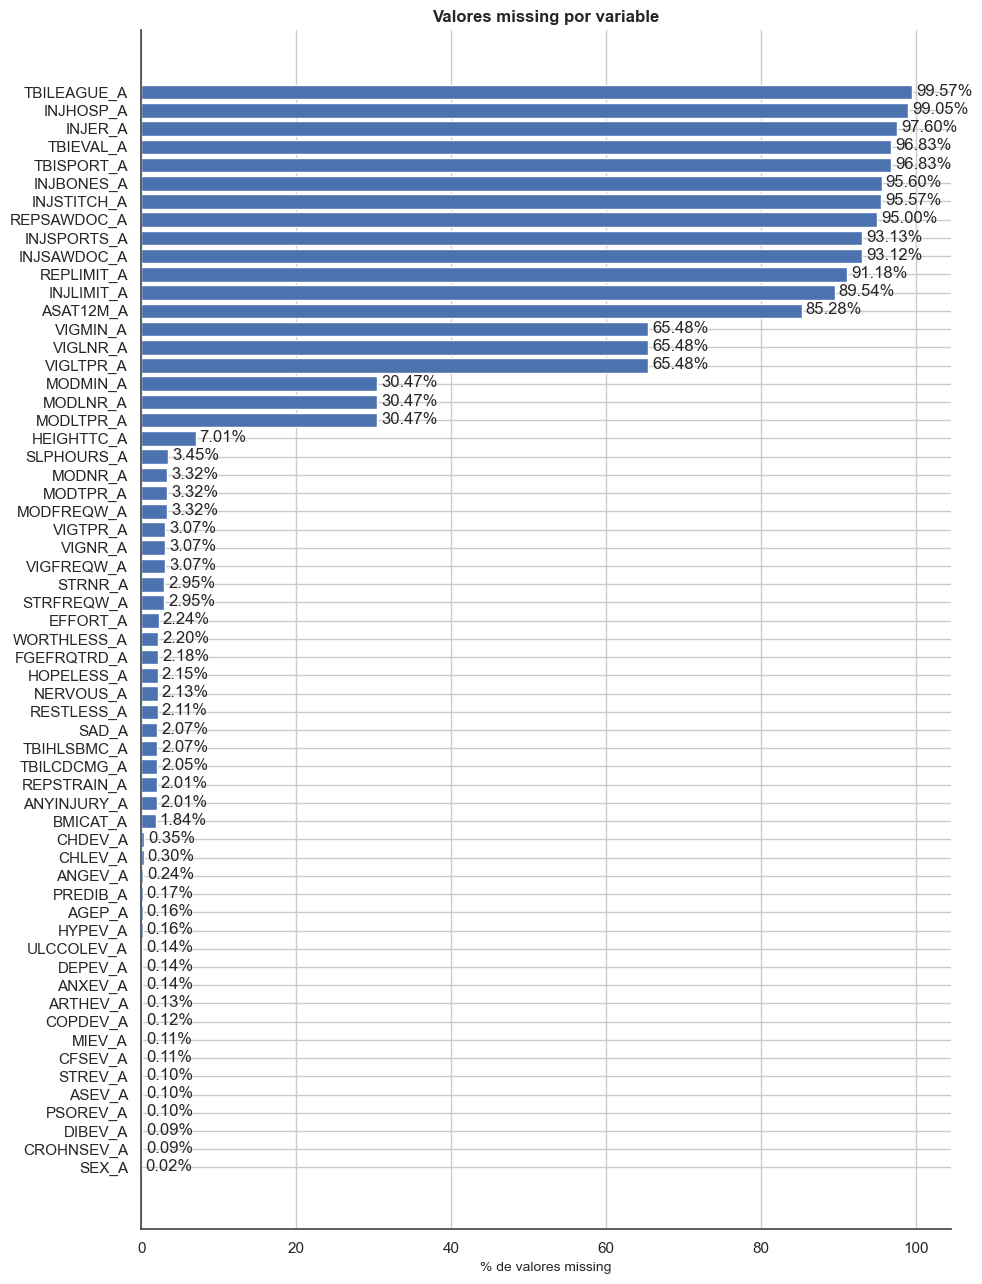

In [922]:
def plot_missing(df, missing_from_df):
    missing = df.isna().mean().sort_values(ascending=False) * 100
    missing_percentage = missing[missing > 0]
    fig, ax = plt.subplots(figsize=(10,13))
    ax.barh(missing_percentage.index[::-1], missing_percentage.values[::-1])
    ax.set_xlabel('% de valores missing')
    ax.set_title('Valores missing por variable')
    for i, v in enumerate(missing_percentage.values[::-1]):
        ax.text(v + 0.5, i - 0.2, f"{v:.2f}%")
    plt.tight_layout()
    plt.show()

plot_missing(df_clean_special_codes, missing)

In [923]:
def verify_missing_structural(df_original, freq_col, duration_col, no_activity=94):
    mascara_no_activity = df_original[freq_col] == no_activity
    mascara_real_zero = df_original[freq_col] == 0

    print(f"Columna {duration_col} depende de {freq_col}:")
    print(f"Grupo 1 (no hace actividad): {mascara_no_activity.sum()}")
    print(f"Grupo 2 (freq=0 redondeado): {mascara_real_zero.sum()}")
    print(f"NaN en Grupo 1: {df_original.loc[mascara_no_activity, duration_col].isna().sum()}")
    print(f"NaN en Grupo 2: {df_original.loc[mascara_real_zero, duration_col].isna().sum()}")


In [924]:
# Verificación de missing values por branching estructural de la encuesta

verify_missing_structural(df_selected, 'VIGFREQW_A', 'VIGMIN_A')
verify_missing_structural(df_selected, 'MODFREQW_A', 'MODMIN_A')

Columna VIGMIN_A depende de VIGFREQW_A:
Grupo 1 (no hace actividad): 20179
Grupo 2 (freq=0 redondeado): 1891
NaN en Grupo 1: 20179
NaN en Grupo 2: 0
Columna MODMIN_A depende de MODFREQW_A:
Grupo 1 (no hace actividad): 8786
Grupo 2 (freq=0 redondeado): 1192
NaN en Grupo 1: 8786
NaN en Grupo 2: 0


Estos missing que quedan tienen sentido por la estructura de la encuesta. Hay preguntas que no van a llegar a ser respondidas por algunos encuestados, por el branching de la estructura de preguntas.

#### Estadísticas descriptivas aplicando variables de muestreo

In [925]:
# from statsmodels.stats.weightstats import DescrStatsW
# from samplics.estimation import TaylorEstimator


def weighted_quantile(values: np.ndarray, weights: np.ndarray, quantiles: float) -> np.ndarray:
    """
    """
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    weighted_quantiles = np.cumsum(weights) - 0.5 * weights
    weighted_quantiles /= np.sum(weights)
    return np.interp(quantiles, weighted_quantiles, values)

def describe_with_sampling(df: pd.DataFrame, columns: list, weight_col: str = 'WTFA_A', 
                           strat_col: str = 'PSTRAT', psu_col: str = 'PPSU') -> pd.DataFrame:
    """
    """

    # Validaciones
    required_columns = [weight_col, strat_col, psu_col]
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas de muestreo: {', '.join(missing_columns)}")

    design = svy.Design(
        stratum = strat_col,
        psu = psu_col,
        wgt = weight_col
    )
    sample = svy.Sample(data = pl.from_pandas(df), design = design)

    summary = []

    for col in columns:
        if col not in df.columns:
            print(f"Columna {col} no encontrada en DataFrame.")
            continue

        try:
            media = sample.estimation.mean(col, drop_nulls=True).to_polars()
            mediana = sample.estimation.median(col, drop_nulls=True).to_polars()
            mascara = df[col].notna() & df[weight_col].notna()
            data = df.loc[mascara, col].to_numpy()
            pesos = df.loc[mascara, weight_col].to_numpy()
            q1 = weighted_quantile(data, pesos, 0.25) # aproximados sin diseño muestral completo
            q3 = weighted_quantile(data, pesos, 0.75)

        except Exception as e:
            print(f"Error al calcular estadísticas ponderadas para la columna {col}: {e}")
            continue


        summary.append({
            'Variable': col,
            'Media': media['est'][0],
            'SE': media['se'][0],
            'CV': media['cv'][0],
            'LCI': media['lci'][0],
            'UCI': media['uci'][0],
            'Mínimo': df[col].min(),
            'Máximo': df[col].max(),
            '25%': q1,
            '50%': mediana['est'][0],
            '75%': q3,
            'IQR': q3 - q1
        })

    return pd.DataFrame(summary)


In [926]:
df_descriptive = describe_with_sampling(df_clean_special_codes, numeric_vars, weight_col='WTFA_A', strat_col='PSTRAT', psu_col='PPSU')
display(df_descriptive.round(3))

,Variable,Media,SE,CV,LCI,UCI,Mínimo,Máximo,25%,50%,75%,IQR
0,MODFREQW_A,2.960,0.030,0.010,2.902,3.018,-1.0,28.0,0.0,2.0,5.0,5.0
1,MODMIN_A,61.333,0.614,0.010,60.127,62.539,1.0,720.0,30.0,45.0,60.0,30.0
2,MODNR_A,2.366,0.037,0.015,2.294,2.438,-1.0,365.0,0.0,2.0,3.0,3.0
3,MODLNR_A,26.408,0.289,0.011,25.841,26.975,1.0,240.0,2.0,30.0,40.0,38.0
4,VIGFREQW_A,0.963,0.016,0.016,0.932,0.994,-1.0,28.0,0.0,0.0,1.0,1.0
5,VIGMIN_A,57.904,0.615,0.011,56.695,59.112,1.0,720.0,30.0,45.0,60.0,30.0
6,VIGNR_A,1.019,0.023,0.022,0.974,1.063,-1.0,365.0,0.0,0.0,1.0,1.0
7,VIGLNR_A,25.592,0.370,0.014,24.865,26.318,1.0,270.0,2.0,30.0,35.0,33.0
8,STRFREQW_A,1.341,0.019,0.014,1.304,1.377,-1.0,28.0,0.0,0.0,2.0,2.0
9,STRNR_A,1.231,0.025,0.021,1.181,1.281,-1.0,365.0,0.0,0.0,2.0,2.0


#### Plots

In [927]:
# Diccionario de labels por variable
labels_dict = {
    # --- Actividad moderada ---
    'MODFREQW_A': {-1: 'No puede'}, # numérica
    'MODMIN_A': {}, # numérica
    'MODNR_A': {-1: 'No puede'}, # numérica
    'MODTPR_A': {-1: 'No puede', 0: 'Nunca', 1: 'Por día', 2: 'Por semana', 3: 'Por mes', 4: 'Por año'},
    'MODLNR_A': {}, # numérica
    'MODLTPR_A': {1: 'Minutos', 2: 'Horas'},

    # --- Actividad vigorosa ---
    'VIGFREQW_A': {-1: 'No puede'},
    'VIGMIN_A': {}, # numérica
    'VIGNR_A': {-1: 'No puede'},
    'VIGTPR_A': {-1: 'No puede', 0: 'Nunca', 1: 'Por día', 2: 'Por semana', 3: 'Por mes', 4: 'Por año'},
    'VIGLNR_A': {},# numérica
    'VIGLTPR_A': {1: 'Minutos', 2: 'Horas'},

    # --- Fortalecimiento muscular ---
    'STRFREQW_A': {-1: 'No puede'},
    'STRNR_A': {-1: 'No puede'},

    # --- Escala K6 (malestar psicológico) ---
    'SAD_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'NERVOUS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'RESTLESS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'HOPELESS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'EFFORT_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},
    'WORTHLESS_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},

    # --- Condiciones "Ever had" ---
    'ANXEV_A': {1: 'Sí', 2: 'No'},
    'DEPEV_A': {1: 'Sí', 2: 'No'},
    'ASEV_A': {1: 'Sí', 2: 'No'},
    'ASAT12M_A': {1: 'Sí', 2: 'No'},
    'COPDEV_A': {1: 'Sí', 2: 'No'},
    'DIBEV_A': {1: 'Sí', 2: 'No'},
    'PREDIB_A': {1: 'Sí', 2: 'No'},
    'HYPEV_A': {1: 'Sí', 2: 'No'},
    'CHLEV_A': {1: 'Sí', 2: 'No'},
    'CHDEV_A': {1: 'Sí', 2: 'No'},
    'ANGEV_A': {1: 'Sí', 2: 'No'},
    'MIEV_A': {1: 'Sí', 2: 'No'},
    'STREV_A': {1: 'Sí', 2: 'No'},

    # --- Demográficas ---
    'AGEP_A': {}, # numérica
    'SEX_A': {1: 'Hombre', 2: 'Mujer'},
    'BMICAT_A': {1: 'Bajo peso', 2: 'Peso normal', 3: 'Sobrepeso', 4: 'Obesidad'},
    'HEIGHTTC_A': {}, # numérica

    # --- Fatiga y condiciones restantes ---
    'CFSEV_A': {1: 'Sí', 2: 'No'},
    'FGEFRQTRD_A': {1: 'Nunca', 2: 'Algunos días', 3: 'La mayoría de días', 4: 'Todos los días'},
    'SLPHOURS_A': {},
    'ARTHEV_A': {1: 'Sí', 2: 'No'},
    'CROHNSEV_A': {1: 'Sí', 2: 'No'},
    'ULCCOLEV_A': {1: 'Sí', 2: 'No'},
    'PSOREV_A': {1: 'Sí', 2: 'No'},
    'ANYINJURY_A': {1: 'Sí', 2: 'No'},
    'REPSTRAIN_A': {1: 'Sí', 2: 'No'},
    'REPLIMIT_A': {1: 'Sí', 2: 'No'},
    "REPSAWDOC_A": {1: 'Sí', 2: 'No'},
    "INJSPORTS_A": {1: 'Sí', 2: 'No'},
    "INJLIMIT_A": {1: 'Sí', 2: 'No'},
    "INJSAWDOC_A": {1: 'Sí', 2: 'No'},
    "INJER_A": {1: 'Sí', 2: 'No'},
    "INJHOSP_A": {1: 'Sí', 2: 'No'},
    "INJBONES_A": {1: 'Sí', 2: 'No'},
    "INJSTITCH_A": {1: 'Sí', 2: 'No'},
    "TBILCDCMG_A": {1: 'Sí', 2: 'No'},
    "TBISPORT_A": {1: 'Sí', 2: 'No'},
    "TBIHLSBMC_A": {1: 'Sí', 2: 'No'},
    "TBILEAGUE_A": {1: 'Sí', 2: 'No'},
    "TBIEVAL_A": {1: 'Sí', 2: 'No'},
}


In [928]:
# grupos temáticos de variables
variable_groups = {
    'actividad_fisica': physical_activity_vars,
    'salud_mental': psych_distress_vars,
    'respiratorio': respiratory_vars,
    'demograficas': basic_vars,
    'lesiones': injury_vars,
    'factores_riesgo_metabolico': metabolic_vars,
    'eventos_cardiovasculares': cardiovasc_vars,
    'fatiga': fatigue_vars,
    'autoinmune_inflamatorio': auto_infl_vars
}

In [929]:
# Estilo para plots
sns.set_theme(style="whitegrid", font_scale=1.0)
matplotlib.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#4a4a4a',
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
})

COLOR_BASE = "#3B6DB3"
COLOR_MEDIAN = "#D8622C"

In [930]:
var_descriptions = {
    'MODFREQW_A': 'Frecuencia actividad moderada (veces/semana)',
    'MODMIN_A': 'Duración actividad moderada (minutos)',
    'MODNR_A': 'Actividad moderada - número (crudo)',
    'MODTPR_A': 'Actividad moderada - unidad de tiempo',
    'MODLNR_A': 'Duración actividad moderada - número (crudo)',
    'MODLTPR_A': 'Duración actividad moderada - unidad de tiempo',
    'VIGFREQW_A': 'Frecuencia actividad vigorosa (veces/semana)',
    'VIGMIN_A': 'Duración actividad vigorosa (minutos)',
    'VIGNR_A': 'Actividad vigorosa - número (crudo)',
    'VIGTPR_A': 'Actividad vigorosa - unidad de tiempo',
    'VIGLNR_A': 'Duración actividad vigorosa - número (crudo)',
    'VIGLTPR_A': 'Duración actividad vigorosa - unidad de tiempo',
    'STRFREQW_A': 'Frecuencia fortalecimiento muscular (veces/semana)',
    'STRNR_A': 'Fortalecimiento muscular - número (crudo)',

    'ANXEV_A': 'Ansiedad (diagnóstico)',
    'DEPEV_A': 'Depresión (diagnóstico)',
    'SAD_A': 'Frecuencia sentirse triste (K6)',
    'NERVOUS_A': 'Frecuencia sentirse nervioso (K6)',
    'RESTLESS_A': 'Frecuencia sentirse inquieto (K6)',
    'HOPELESS_A': 'Frecuencia sentirse sin esperanza (K6)',
    'EFFORT_A': 'Frecuencia sentir que todo requiere esfuerzo (K6)',
    'WORTHLESS_A': 'Frecuencia sentirse inútil (K6)',

    'ASEV_A': 'Asma (diagnóstico)',
    'ASAT12M_A': 'Asma diagnosticada en últimos 12 meses',
    'COPDEV_A': 'EPOC / enfisema / bronquitis crónica',

    'DIBEV_A': 'Diabetes (diagnóstico)',
    'PREDIB_A': 'Prediabetes (diagnóstico)',
    'HYPEV_A': 'Hipertensión (diagnóstico)',
    'CHLEV_A': 'Colesterol alto (diagnóstico)',
    'CHDEV_A': 'Enfermedad coronaria (diagnóstico)',
    'ANGEV_A': 'Angina de pecho (diagnóstico)',
    'MIEV_A': 'Infarto de miocardio (diagnóstico)',
    'STREV_A': 'Ictus / accidente cerebrovascular (diagnóstico)',

    'AGEP_A': 'Edad (años)',
    'SEX_A': 'Sexo',
    'BMICAT_A': 'Categoría de índice de masa corporal',
    'HEIGHTTC_A': 'Altura (pulgadas)',

    'CFSEV_A': 'Síndrome de fatiga crónica (diagnóstico)',
    'FGEFRQTRD_A': 'Frecuencia de sentirse cansado (últimos 3 meses)',
    'SLPHOURS_A': 'Horas de sueño en un período de 24 horas',
    'ARTHEV_A': 'Artritis / artritis reumatoide / gota / lupus / fibromialgia',
    'CROHNSEV_A': 'Enfermedad de Crohn (diagnóstico)',
    'ULCCOLEV_A': 'Colitis ulcerosa (diagnóstico)',
    'PSOREV_A': 'Psoriasis (diagnóstico)',

    'ANYINJURY_A': 'Tuvo alguna lesión en últimos 3m',
    'REPSTRAIN_A': 'Lesión por esfuerzo repetitivo RSI (diagnóstico)',
    'REPLIMIT_A': 'RSI limitó actividad por >= 24h',
    'REPSAWDOC_A': 'Evaluado por médico por RSI',
    'INJSPORTS_A': 'Lesión por deporte',
    'INJLIMIT_A': 'Lesión limitó actividad por >= 24h', 
    'INJSAWDOC_A': 'Lesión evaluada por médico', 
    'INJER_A': 'Lesión atendida en emergencias', 
    'INJHOSP_A': 'Lesión atendida en hospital', 
    'INJBONES_A': 'Lesión con hueso roto', 
    'INJSTITCH_A': 'Lesión con puntadas',
    'TBILCDCMG_A': 'TBI con aturdimiento/perdida de memoria/conocimiento en 12m',
    'TBISPORT_A': 'TBI sucedió entrenando o compitiendo', 
    'TBIHLSBMC_A': 'TBI produjo dolor, sensibilidad, problemas de equilibrio en 12m', 
    'TBILEAGUE_A': 'Evento TBI durante actividad de equipo/liga',
    'TBIEVAL_A': 'Evento TBI evaluado por médico' 
}

##### Distribuciones

In [931]:
def plot_numeric_var(df, col, ax):
    data = df[col].dropna()
    sns.histplot(data, ax=ax, color=COLOR_BASE, linewidth=0.2, bins=30)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.set_title(col)
    median = data.median()
    ax.axvline(median, color=COLOR_MEDIAN, linestyle='--', linewidth=1.0, alpha=0.85)

def plot_categoric_var(df, col, ax, labels):
    data = df[col].value_counts().sort_index()
    col_labels = [labels.get(col, {}).get(i, str(i)) for i in data.index]
    ax.bar(col_labels, data.values, color=COLOR_BASE, linewidth=0.2)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(col)
    # ax.tick_params(axis='x', labelsize=10, rotation=45)
    plt.setp(ax.get_xticklabels(), rotation=60, ha='right', fontsize=10)

def plot_hybrid_var(df, col, ax, labels):
    data = df[col].dropna()
    no_by_incap = (data == -1).sum()
    regular_numeric = data[data >= 0]
    sns.histplot(regular_numeric, ax=ax, color=COLOR_BASE, linewidth=0.2, bins=30)
    #barra extra para mostrara a quienes no realizan actividad por incapacidad
    xmin, xmax = ax.get_xlim()
    xrange = xmax - xmin
    minusonepad = max(xrange * 0.10, 3)
    xmargin = max(xrange * 0.05, 1.5)
    xoffset = -(minusonepad + xmargin)/ 2
    ax.set_xlim(xoffset - xmargin, xmax)
    ax.bar(x=[xoffset], height=[no_by_incap], width=xmargin * 0.8, color=COLOR_MEDIAN)
    xticks = [t for t in ax.get_xticks() if t >= 0] #forzando el -1 en los histplots
    ax.set_xticks([xoffset] + xticks)
    ax.set_xticklabels([-1] + [str(int(t)) for t in xticks])
    ytext = ax.get_ylim()[1] * 0.03
    ax.text(xoffset, ytext , str(no_by_incap), ha='center', va='bottom', fontsize=8, 
            color=COLOR_MEDIAN, fontweight = 'bold')
    ##
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(col)
    # ax.tick_params(axis='x', labelsize=10, rotation=45)

def plot_variable_group(df, group_name, variable_groups, labels, numeric_vars, categorical_vars, 
                        var_descriptions, column_num):
    columns = variable_groups[group_name]
    n_rows = -(-len(columns) // column_num)

    fig, axes = plt.subplots(n_rows, column_num, figsize=(15, 3.6 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]

        if col in categorical_vars:
            var_type = "categorical"
        elif col in numeric_vars:
            if labels.get(col, {}):
                var_type = "hybrid"
            else:
                var_type = "numeric"
        else:
            raise ValueError(f"{col} no está en numeric_vars ni categorical_vars.")
        # print(col, ' -> ', var_type)

        if var_type == "categorical":
            plot_categoric_var(df, col, ax, labels)
        elif var_type == "numeric":
            plot_numeric_var(df, col, ax)
        else:
            plot_hybrid_var(df, col, ax, labels)
            # continue

    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(group_name, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    leyenda = '\n'.join(f"{col}: {var_descriptions.get(col, 'sin descripción')}" for col in columns)
    fig.text(0.02, -0.02, leyenda, fontsize=8, va='top', ha='left', family='monospace')


    plt.show()



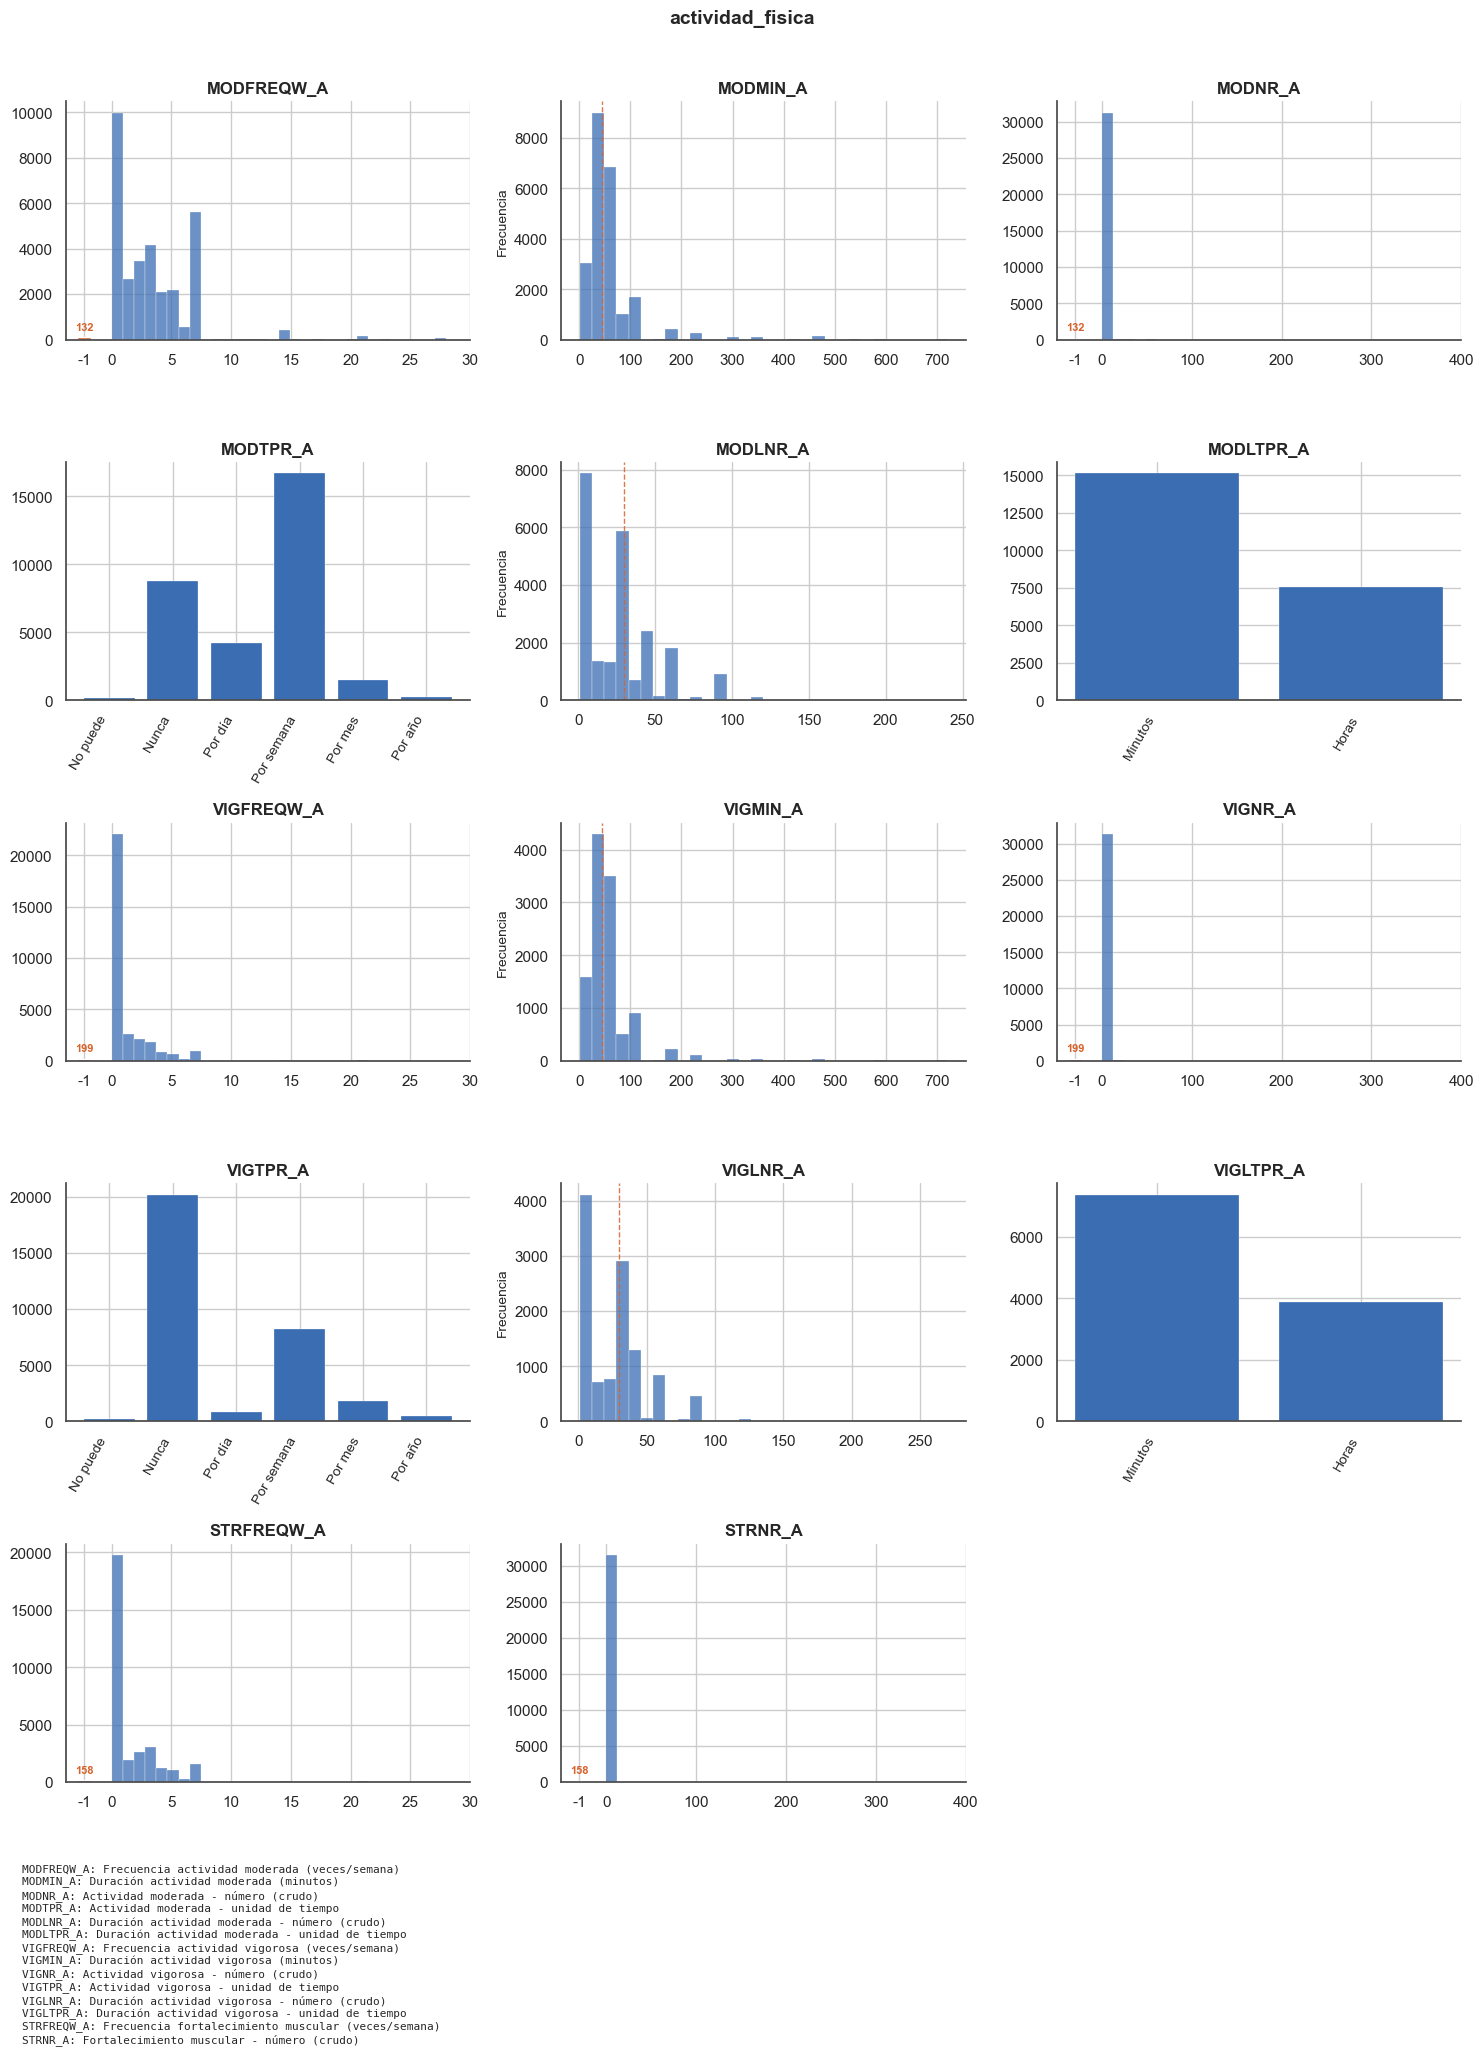

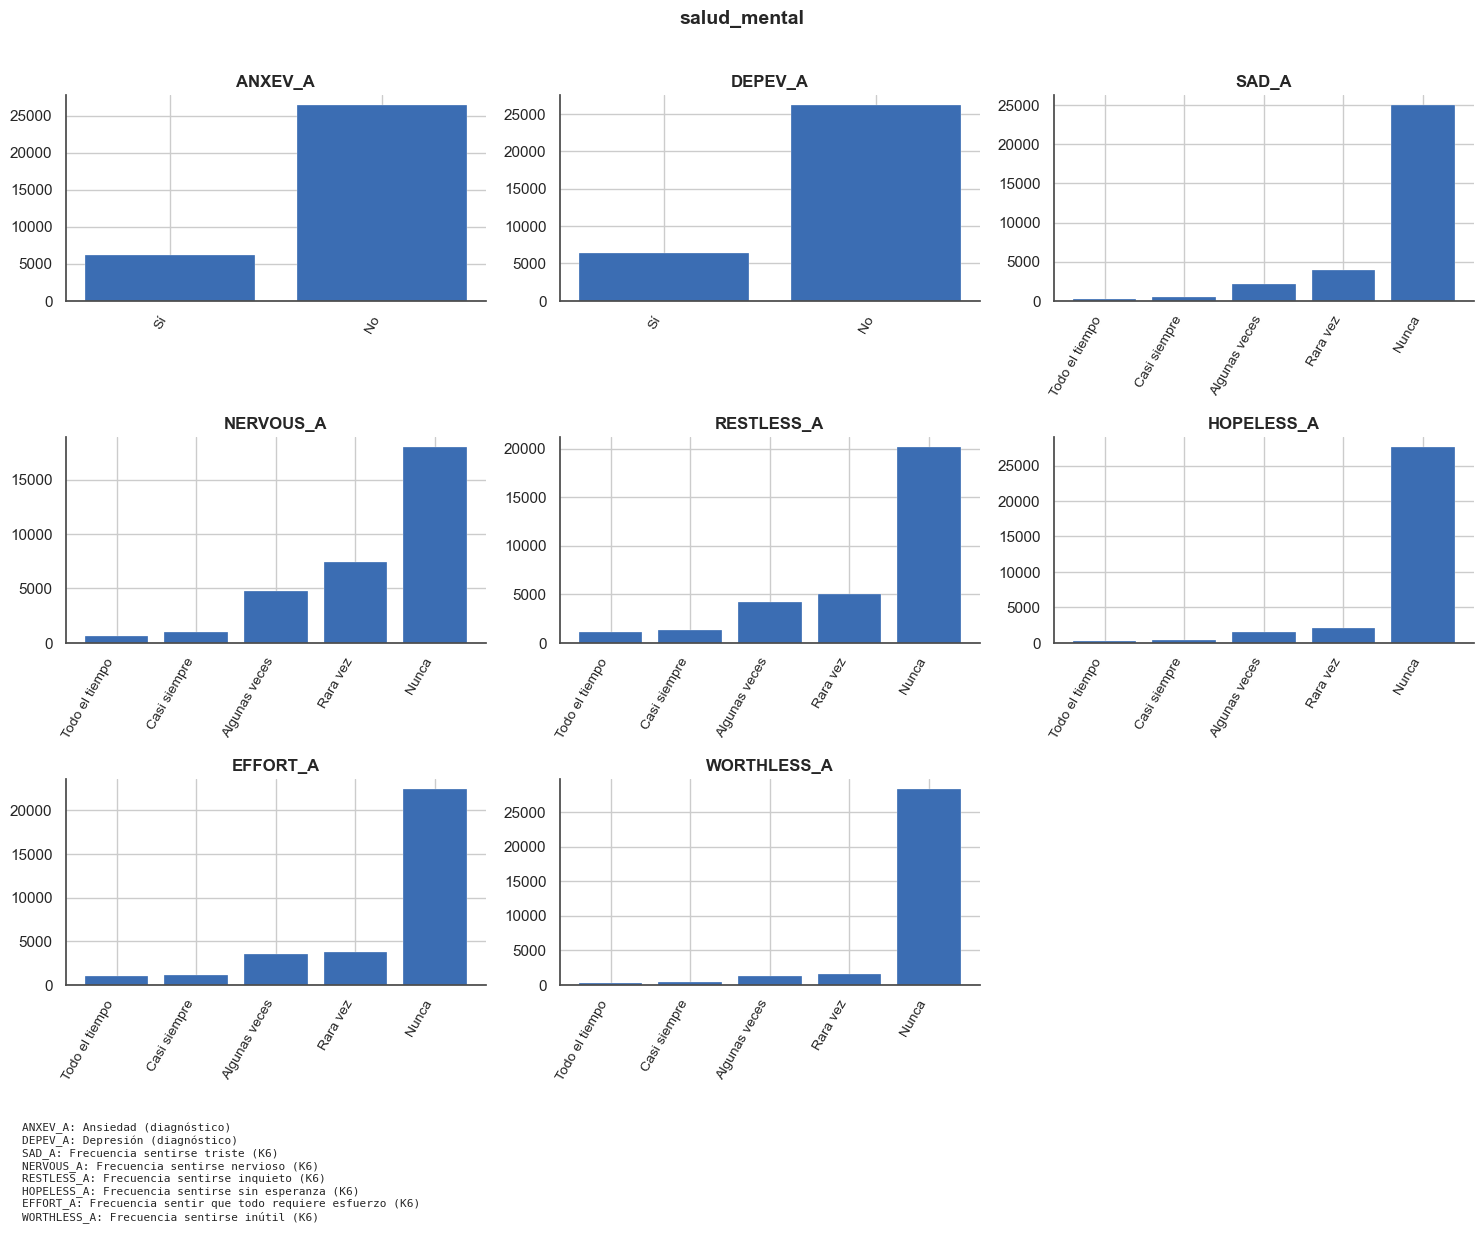

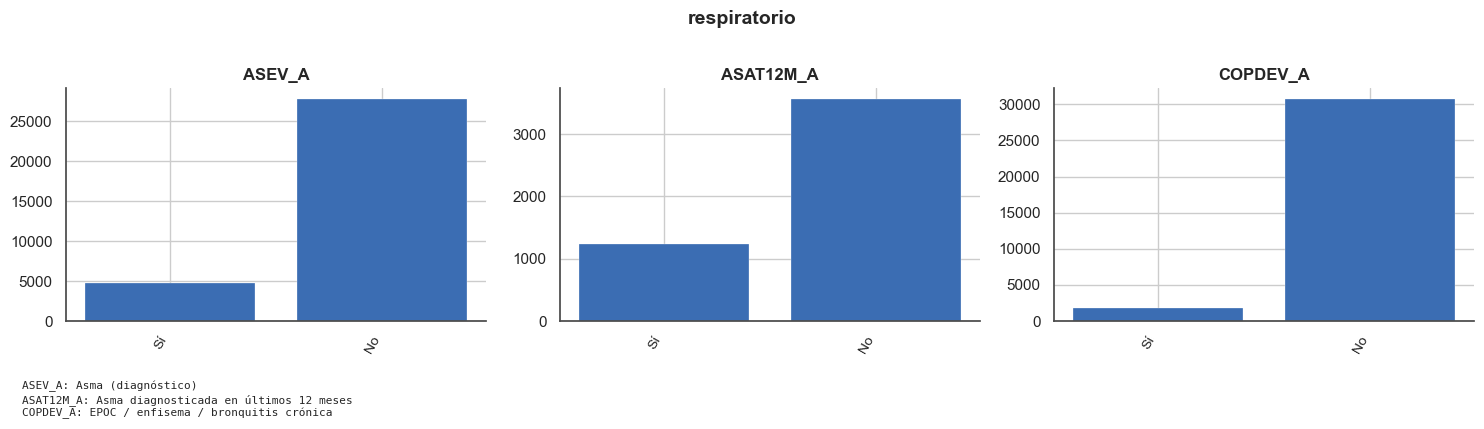

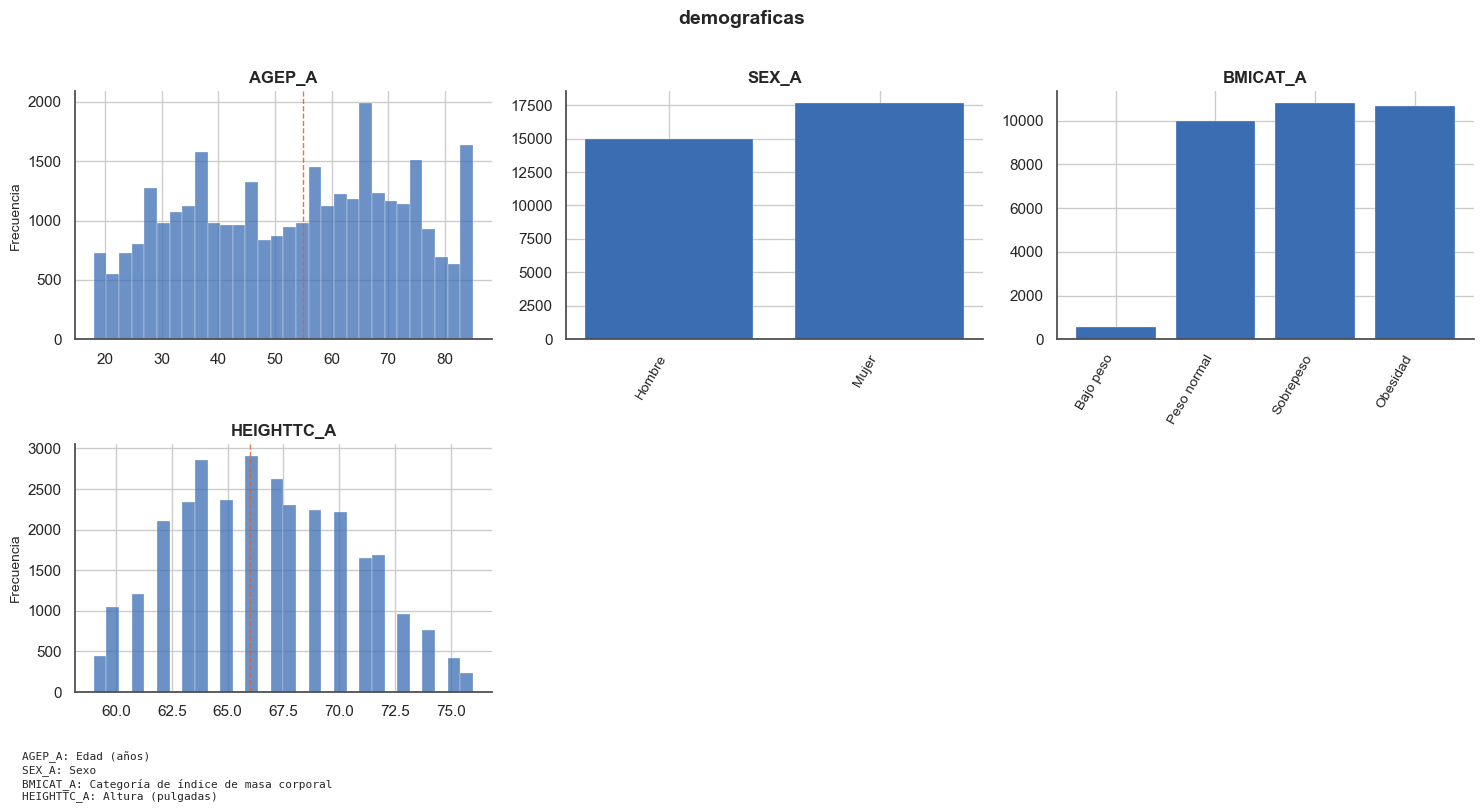

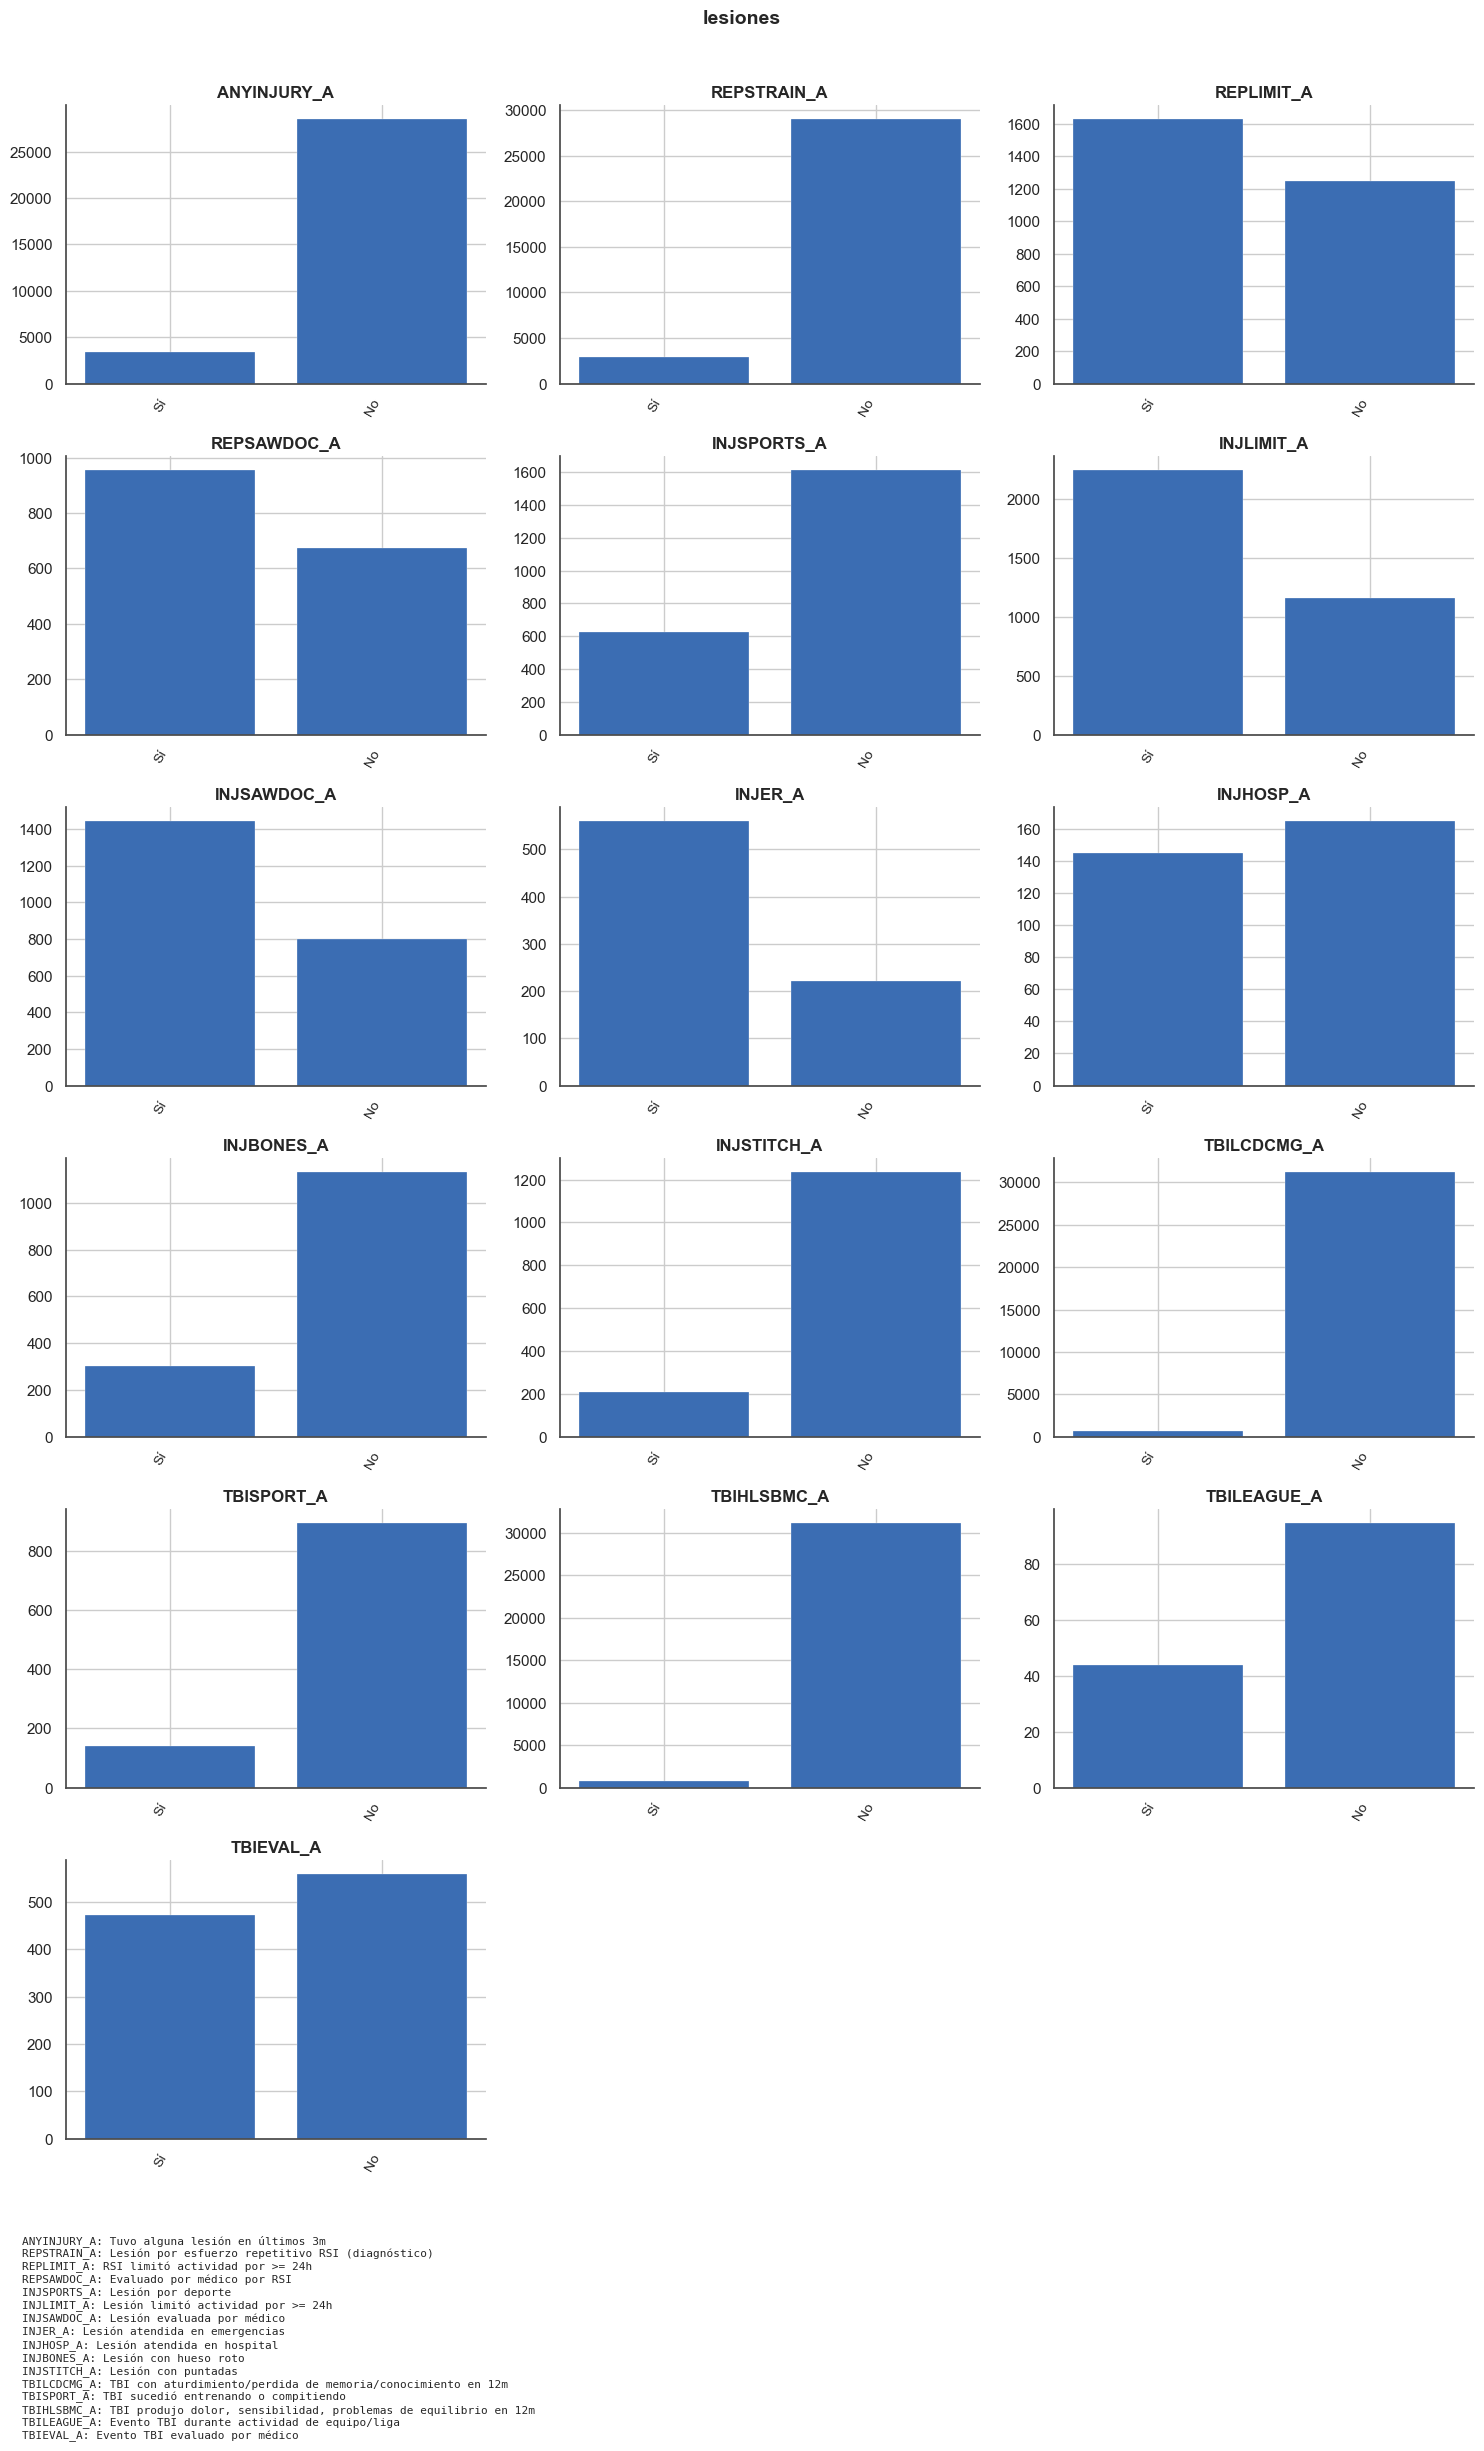

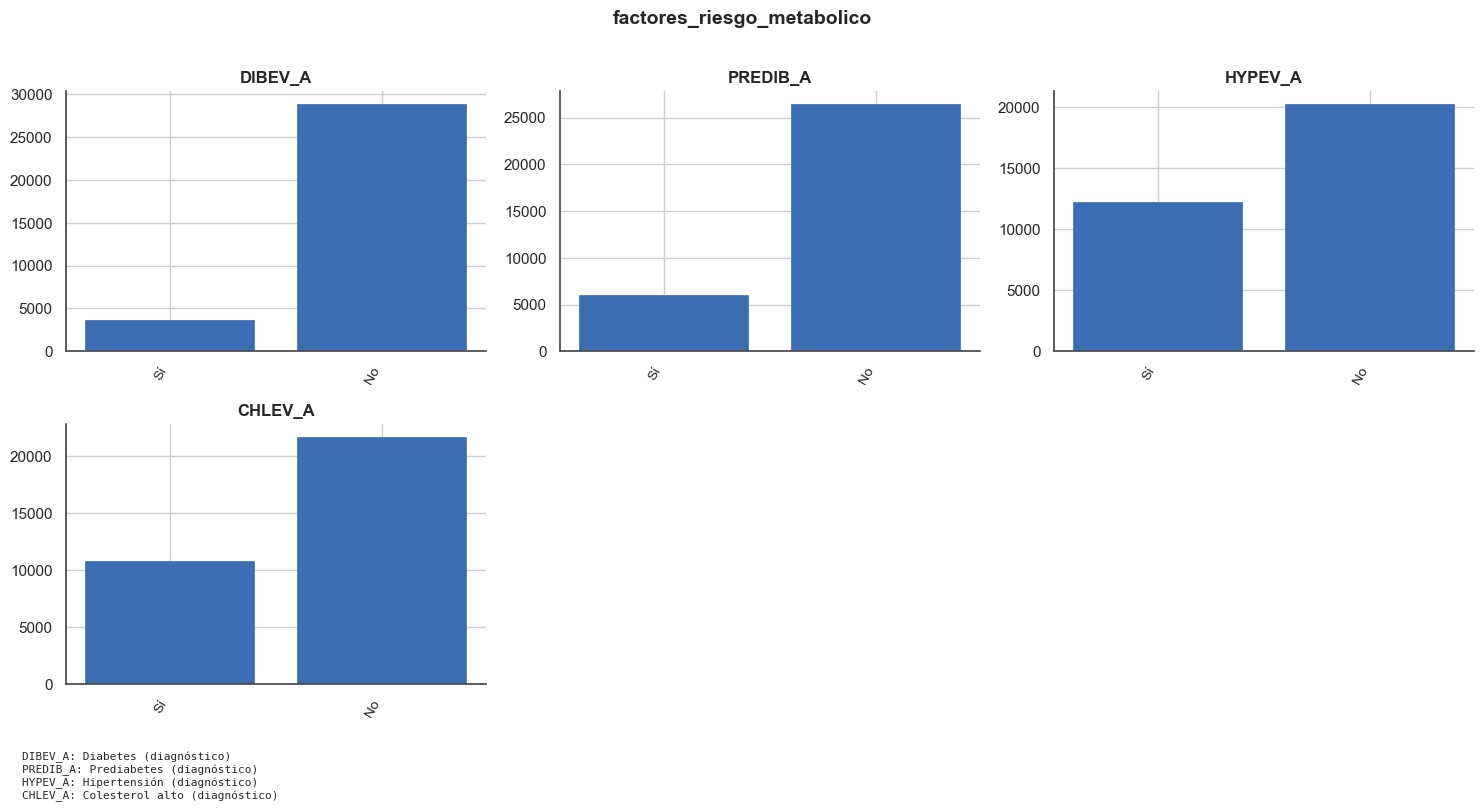

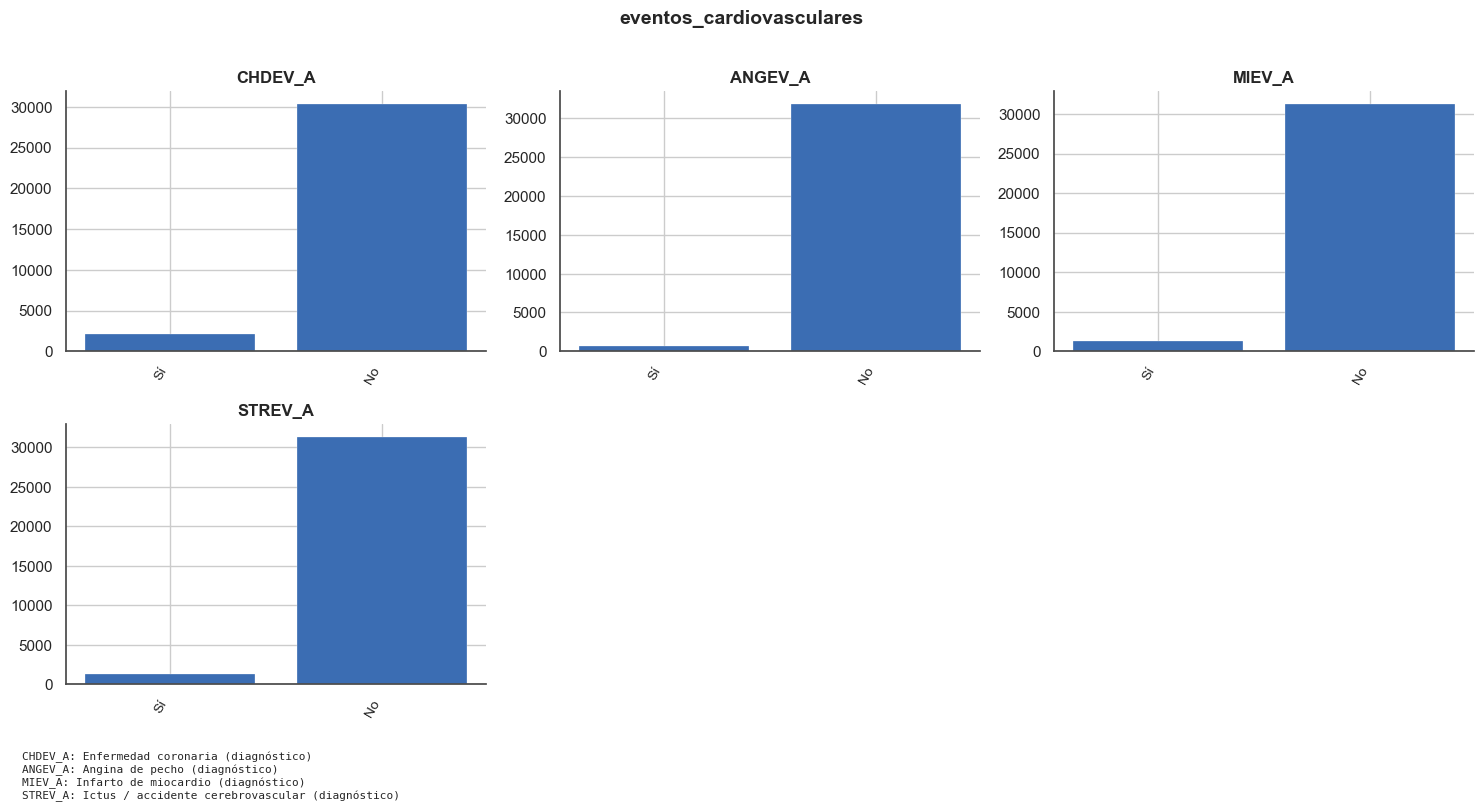

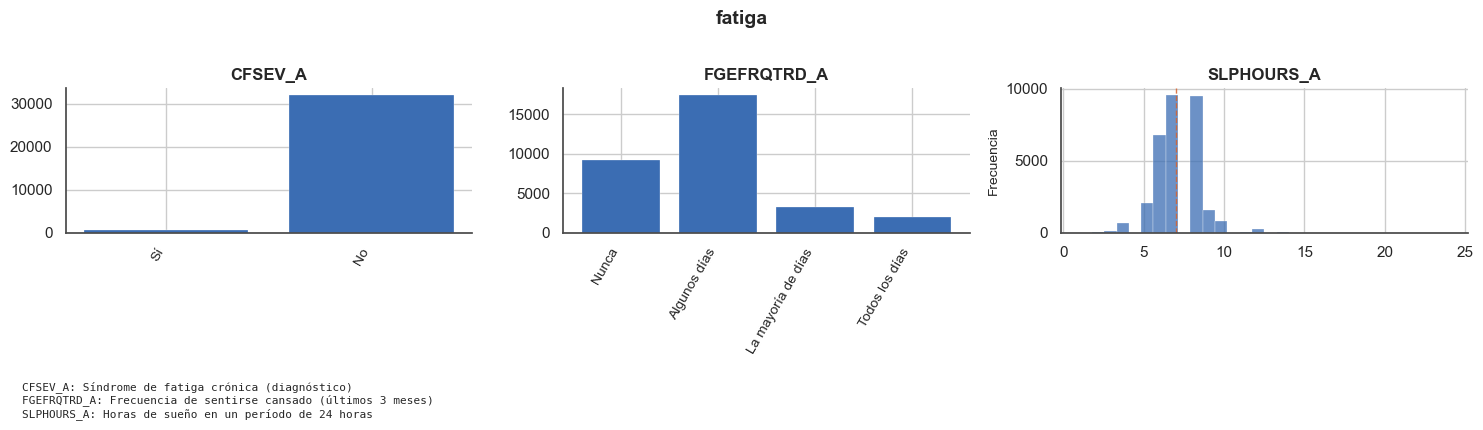

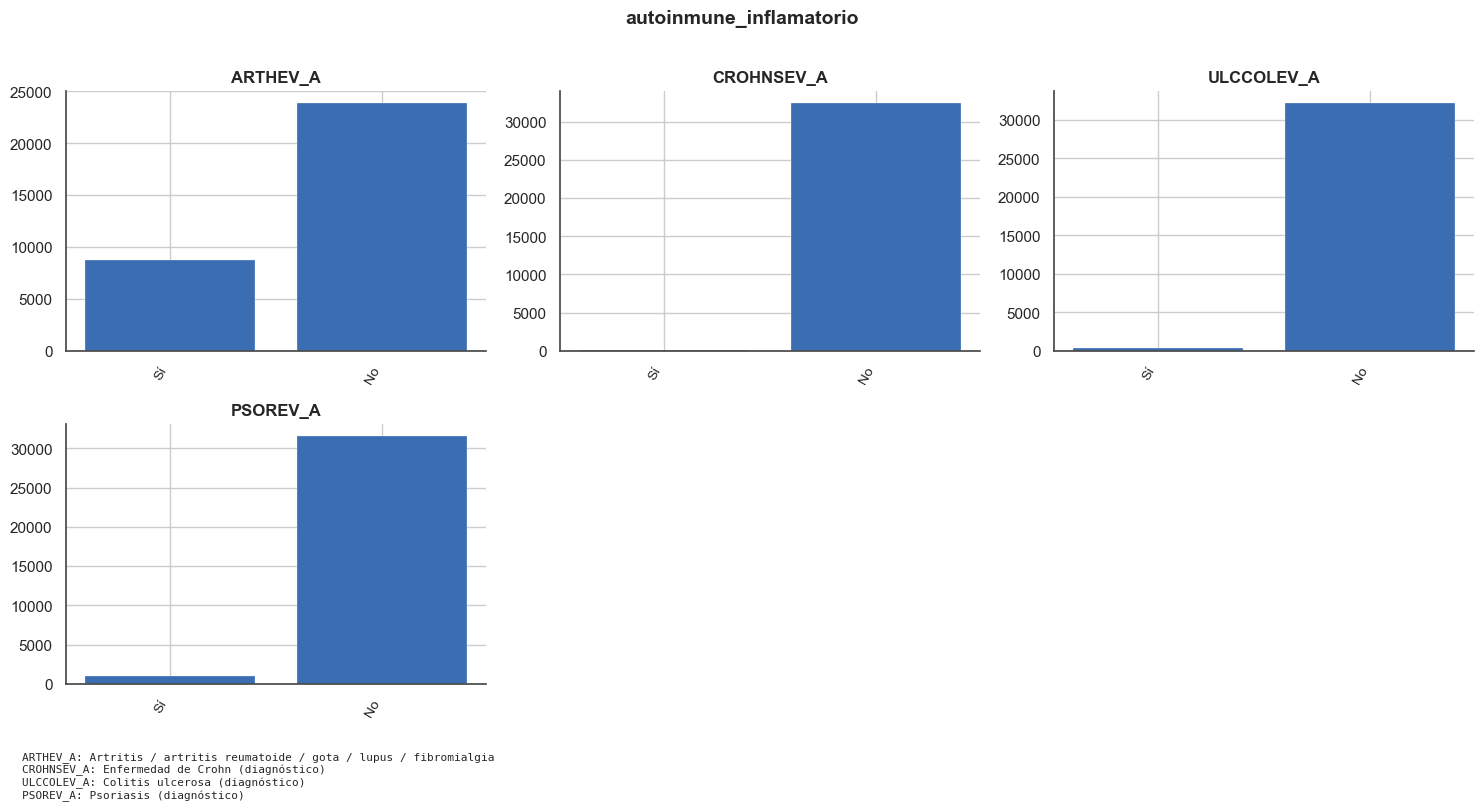

In [932]:
for group_name in variable_groups:
    plot_variable_group(df_clean_special_codes, group_name, variable_groups, 
                        labels_dict, numeric_vars, categorical_vars, var_descriptions, 3)

##### Boxplots

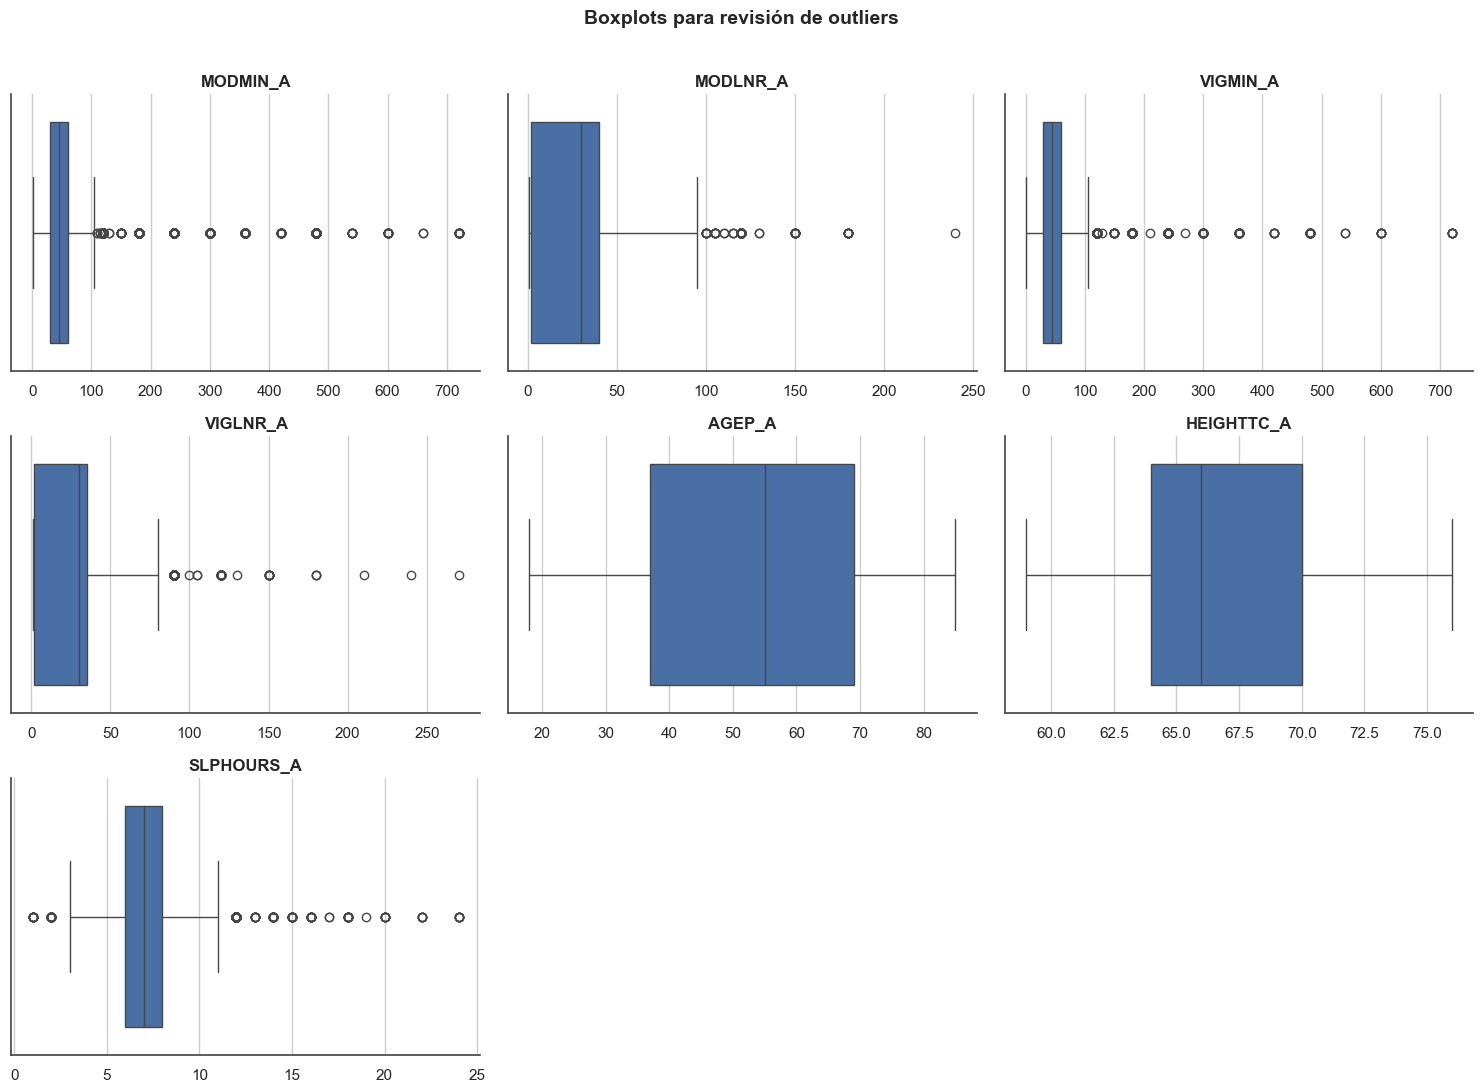

In [933]:
real_numeric_vars = ['MODMIN_A', 'MODLNR_A', 'VIGMIN_A', 'VIGLNR_A', 'AGEP_A', 'HEIGHTTC_A', 'SLPHOURS_A']

def plot_boxplot_var(df, col, ax):
    data = df[col].dropna()
    sns.boxplot(x=data, ax=ax, color=COLOR_BASE)
    ax.set_title(col)
    ax.set_xlabel('')

def num_vars_to_boxplot(df, numvars):
    n_cols = 3
    n_rows = -(-len(numvars) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize= (15, 3.6 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numvars):
        ax = axes[i]
        plot_boxplot_var(df, col, ax)

    for j in range(len(numvars), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Boxplots para revisión de outliers', fontsize = 14, fontweight='bold', y = 1.01)
    plt.tight_layout()
    plt.show()

num_vars_to_boxplot(df_clean_special_codes, real_numeric_vars)


**Observaciones:**
Mi razonamiento al ver estos boxplots se que aun quedan muchos outliers en las variables numericas de actividad física, pero aun siendo outliers, no son errores (que ya fueron limpiados), mas bien son datos que me interesan. Parece que la mayoría de la gente encuestada no hace mucho ejercicio ni moderadamente, pero creo que la relacion entre datos con ejercicio y mi variable objetivo, asi como datos con poco ejercicio y mi variable objetivo, pueden darme informacion interesante.

#### Creación de variable objetivo y

In [934]:
# Creación de variable objetivo y

# X - > ansiedad preexistente, depresion preexistente, asma crónica, lesiones anteriores, actividad fisica
# Y - > riesgo de lesión o flare up de ansiedad/depresion o flare up de asma

df_eda = df_clean_special_codes.copy()

# Variable objetivo para evento de lesión

df_eda['lesion_repentina'] = np.where(
    df_eda['ANYINJURY_A'] == 2, 0,
    np.where(
        df_eda['INJLIMIT_A'] == 2, 1,
        np.where(
            df_eda['INJSAWDOC_A'] == 2, 2,
            np.where(
                (df_eda['INJSAWDOC_A'] == 1) |
                (df_eda['INJER_A'] == 1) |
                (df_eda['INJHOSP_A'] == 1) |
                (df_eda['INJBONES_A'] == 1) |
                (df_eda['INJSTITCH_A'] == 1), 3, np.nan
            )
        )
    )
)

df_eda['lesion_repetitiva'] = np.where(
    df_eda['REPSTRAIN_A'] == 2, 0,
    np.where(
        df_eda['REPLIMIT_A'] == 2, 1,
        np.where(
            df_eda['REPSAWDOC_A'] == 2, 2,
            np.where(
                df_eda['REPSAWDOC_A'] == 1, 3, np.nan
            )
        )
    )
)

tbi_general = np.where(
    df_eda['TBIHLSBMC_A'] == 1, 1,
    np.where(
        df_eda['TBIHLSBMC_A'] == 2, 0, np.nan
    )
)
tbi_peligro = np.where(
    df_eda['TBILCDCMG_A'] == 1, 1,
    np.where(
        df_eda['TBILCDCMG_A'] == 2, 0, np.nan
    )
)
tbi_evento = (df_eda['TBIHLSBMC_A'] == 1) | (df_eda['TBILCDCMG_A'] == 1)
tbi_eval = np.where(
    tbi_evento & (df_eda['TBIEVAL_A'] == 1), 1,
    np.where(
        tbi_evento & (df_eda['TBIEVAL_A'] == 2), 0,
        np.where(
            ~tbi_evento, 0, np.nan
        )
    )
)

df_eda['lesion_cerebral'] = tbi_general + tbi_peligro + tbi_eval


df_eda['y_lesion'] = df_eda[['lesion_repentina', 'lesion_repetitiva', 'lesion_cerebral']].max(axis=1)
df_eda['y_lesion_deportiva'] = np.where(df_eda['INJSPORTS_A'] == 1, 1, 0)

# Variable objetivo para evento malestar psicológico

  # --- Escala K6 (malestar psicológico) ---
    # 'SAD_A': {1: 'Todo el tiempo', 2: 'Casi siempre', 3: 'Algunas veces', 4: 'Rara vez', 5: 'Nunca'},


def calculate_k6_score(n_sad, n_nerv, n_rest, n_hope, n_eff, n_worth):
    cols = [n_sad, n_nerv, n_rest, n_hope, n_eff, n_worth]
    if any(pd.isna(col) for col in cols):
        return np.nan
    else:
        return sum(5 - col for col in cols)

k6_cols = ['SAD_A', 'NERVOUS_A', 'RESTLESS_A', 'HOPELESS_A', 'EFFORT_A', 'WORTHLESS_A']
k6_score = df_eda.apply(lambda row:
                      calculate_k6_score(row['SAD_A'], row['NERVOUS_A'], row['RESTLESS_A'], row['HOPELESS_A'], row['EFFORT_A'], row['WORTHLESS_A']),
                      axis=1)
df_eda['k6_score'] = k6_score
df_eda['y_malestar_psicologico'] = pd.cut(k6_score, 
                                        [0, 5, 13, 25], 
                                        labels=[0, 1, 2],
                                        right=False)

# Variable objetivo para evento flare up respiratorio

df_eda['y_respiratorio'] = np.where(
    df_eda['ASAT12M_A'] == 1, 1,
    np.where(
        df_eda['ASAT12M_A'] == 2, 0, np.nan
    )
)


**Nota sobre `lesion_cerebral`:**

Para la definición de lesiones cerebrales, las variables que la encuestas provee no son en una estructura que va indicando severidad con branching, como es el caso de lesiones repentinas o repetitivas. Por esta razón, el. cálculo de ese grupo de lesiones no es escalado por severidad, sino como suma de indicadores de lesión cerebral.

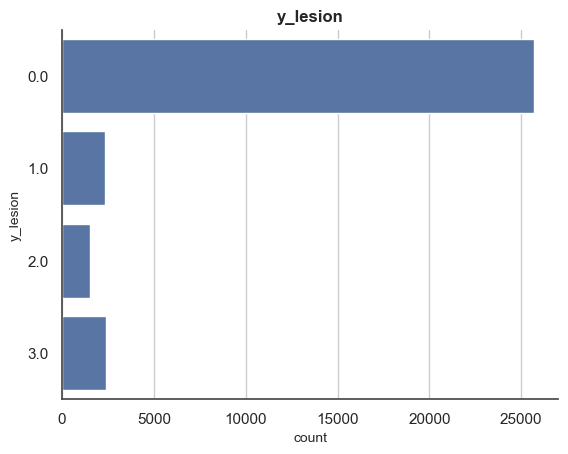

y_lesion
0.0    0.803537
1.0    0.073529
2.0    0.048186
3.0    0.074748
Name: proportion, dtype: float64


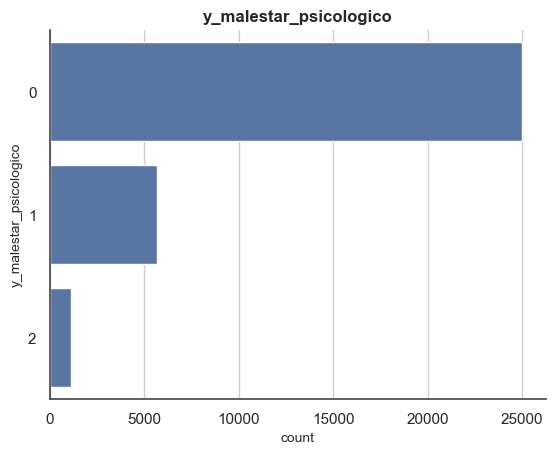

y_malestar_psicologico
0    0.785717
1    0.178512
2    0.035772
Name: proportion, dtype: float64


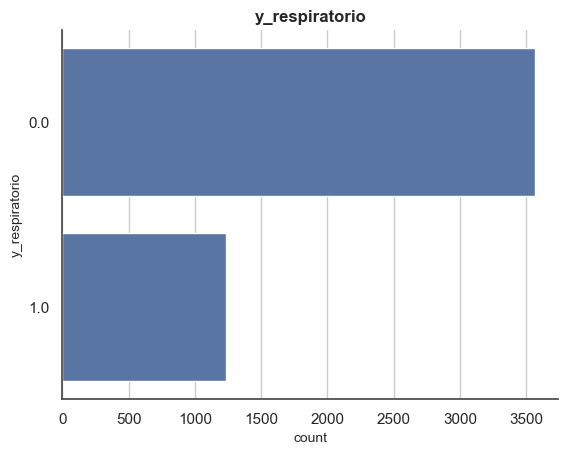

y_respiratorio
0.0    0.742191
1.0    0.257809
Name: proportion, dtype: float64


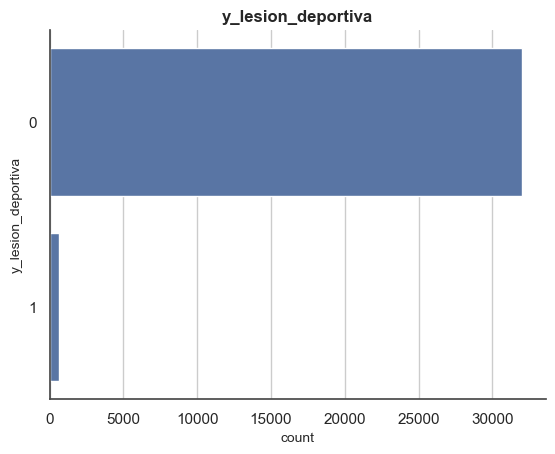

y_lesion_deportiva
0    0.980845
1    0.019155
Name: proportion, dtype: float64


In [935]:
# comprobar balanceo de clases
def balanceo_de_clases(df, var_objetivo):
    sns.countplot(y=var_objetivo, data=df)
    plt.title(var_objetivo)
    plt.show()
    print(df[var_objetivo].value_counts(normalize=True).sort_index())

# tenemos 3 variables objetivo:
variables_objetivo = ['y_lesion', 'y_malestar_psicologico', 'y_respiratorio', 'y_lesion_deportiva']
for y in variables_objetivo:
    balanceo_de_clases(df_eda, y)

**Nota**

En cuanto a y_respiratorio, se estará reduciendo la poblacion para que solo tome en cuenta a personas asmáticas, ya que solo quienes responden que son asmáticos llegan a responder la pregunta que genera la variable objetivo en este caso. En los casos de no asmáticos, el valor es NaN, por lo cual la subpoblación no asmática será excluída intencionalmente para el modelado y entrenamiento correspondiente.

#### Valores únicos

In [936]:
for col in df_clean_special_codes.columns:
    unique_values= np.sort(df_clean_special_codes[col].unique())
    print(f"{col}: {unique_values}")

WTFA_A: [  265.078   266.031   278.586 ... 36928.587 37411.091 38138.226]
PSTRAT: [100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151]
PPSU: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  72  73  74  75
  76  77  78  79  80  81  82  87  89  90  91  92  93  96  97  98 100 101
 102 103 104 108 109 110 112 116 118 127 128 134 139 140 150 151 152 153]
MODFREQW_A: [-1.  0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.
 17. 18. 20. 21. 22. 23. 25. 27. 28. nan]
MODMIN_A: [  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  12.  13.  14.  15.
  16.  17.  18.  20.  21.  22.  23.  24.  25.  26.  2

##### Definición de X

X - > ansiedad preexistente, depresion preexistente, asma crónica, lesiones anteriores, actividad fisica

In [937]:

categorical_features = ['ANXEV_A', 'DEPEV_A', 'ASEV_A', 'SEX_A', 'BMICAT_A']
numeric_features = ['AGEP_A', 'HEIGHTTC_A', 'SLPHOURS_A',
                    'MODMIN_A', 'VIGMIN_A', 
                    'MODFREQW_A', 'VIGFREQW_A', 'STRFREQW_A',
                    'MODNR_A', 'VIGNR_A', 'STRNR_A', 'MODLNR_A', 'VIGLNR_A']
print(f"Numeric: {numeric_features}\nCategorical: {categorical_features}")
features = numeric_features + categorical_features
print(f"Selected features: {features}")
X = df_eda[features].copy()

Numeric: ['AGEP_A', 'HEIGHTTC_A', 'SLPHOURS_A', 'MODMIN_A', 'VIGMIN_A', 'MODFREQW_A', 'VIGFREQW_A', 'STRFREQW_A', 'MODNR_A', 'VIGNR_A', 'STRNR_A', 'MODLNR_A', 'VIGLNR_A']
Categorical: ['ANXEV_A', 'DEPEV_A', 'ASEV_A', 'SEX_A', 'BMICAT_A']
Selected features: ['AGEP_A', 'HEIGHTTC_A', 'SLPHOURS_A', 'MODMIN_A', 'VIGMIN_A', 'MODFREQW_A', 'VIGFREQW_A', 'STRFREQW_A', 'MODNR_A', 'VIGNR_A', 'STRNR_A', 'MODLNR_A', 'VIGLNR_A', 'ANXEV_A', 'DEPEV_A', 'ASEV_A', 'SEX_A', 'BMICAT_A']


#### Correlación

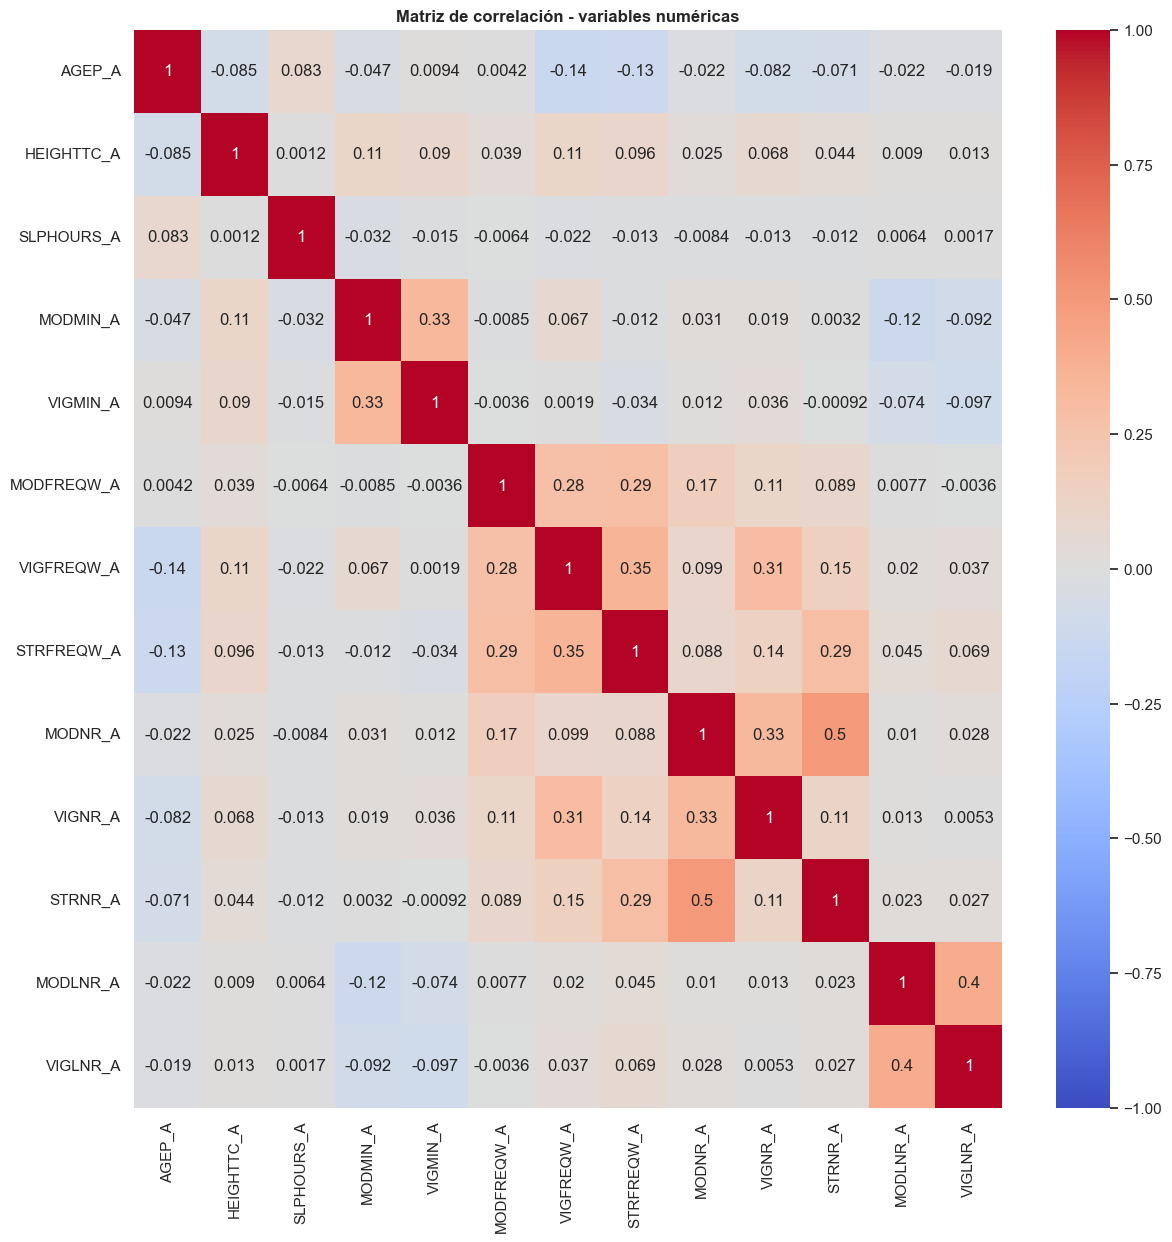

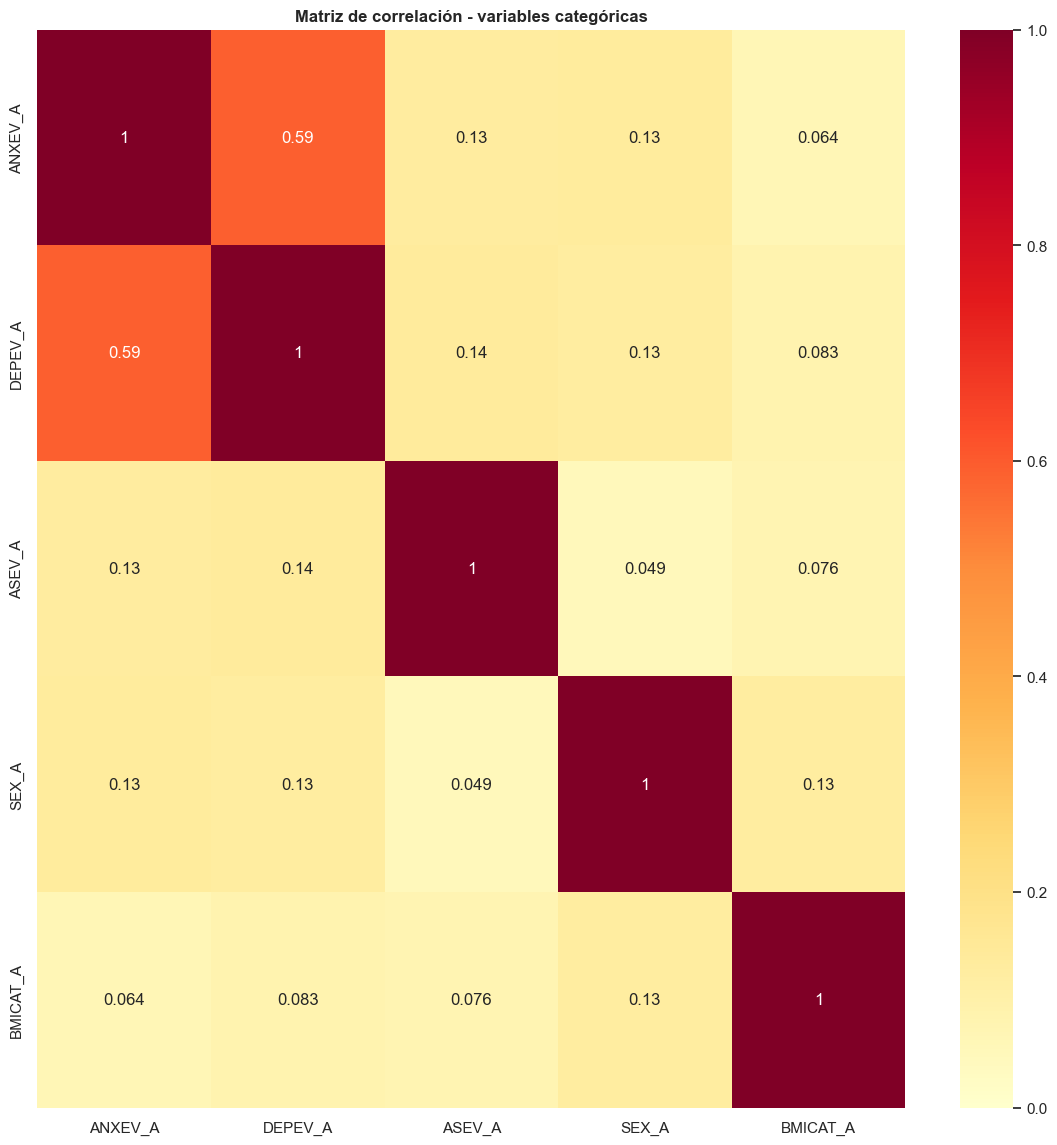

In [938]:
# Correlación de numéricas
corr_matrix_pearson = X[numeric_features].corr(method='pearson')
plt.figure(figsize = (14, 14))
sns.heatmap(
    corr_matrix_pearson,
    annot = True,
    vmin = -1,
    vmax = 1,
    cmap = "coolwarm"
)
plt.title("Matriz de correlación - variables numéricas")
plt.show()


# Correlación de categóricas
def cramers(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    c, r = confusion_matrix.shape
    return np.sqrt((chi2/n)/min(c-1, r-1))

corr_matrix_cramers = pd.DataFrame(
    index=categorical_features, columns=categorical_features,
    dtype=float # para que procese NaNs
)
for col1 in categorical_features:
    for col2 in categorical_features:
        corr_matrix_cramers.loc[col1, col2] = cramers(X[col1], X[col2])
plt.figure(figsize = (14, 14))
sns.heatmap(
    corr_matrix_cramers,
    annot = True,
    vmin = 0,
    vmax = 1,
    cmap = "YlOrRd"
)
plt.title("Matriz de correlación - variables categóricas")
plt.show()



**Nota sobre variables a borrar:**

Incialmente, se pensó que algunas variables de actividad física iban a estar fuertemente correlacionadas entre ellas por ser calculadas a partir de otras, pero no fue así. Según la documentación de NHIS (srvydesc.pdf), las variables 'MODNR_A', 'VIGNR_A', 'STRNR_A', 'MODLNR_A', y 'VIGLNR_A' son utilizadas para calcular las variables FREQ y MIN, normalizadas en unidades comparables. Sería redundante mantenerlas en X, por lo que se eliminan.

In [939]:
cols_a_eliminar = ['MODNR_A', 'VIGNR_A', 'STRNR_A', 'MODLNR_A', 'VIGLNR_A']
numeric_features = [col for col in numeric_features if col not in cols_a_eliminar]
features = numeric_features + categorical_features
X = X.drop(columns=cols_a_eliminar)
columnas_a_mantener = features + sample_vars + variables_objetivo + ['k6_score']
df_fe = df_eda[columnas_a_mantener].copy()

### Resumen del EDA

Luego de explorar los datos obtenidos a partir del dataset resultante de la encuesta NHIS 2024, se encontró la necesidad de modificar el alcance del proyecto, ya que no todos los grupos temáticos de variables contenían columnas que identificaran casos recientes de condiciones crónicas además de las columnas de diagnóstico. Por lo tanto, se estableció que el modelo predictor iba a solo acaparar variables relacionadas a lesiones, ansiedad, depresión y asma.

Los valores de las variables recibieron el tratamiento esperado de acuerdo a los códigos especiales definidos en la documentación oficial d NHIS. Para los resumenes de estadística descriptiva se tomaron en cuenta las variables muestrales WTFA_A, PSTRAT y PPSU.

Al llegar a la definición de la variable objetivo Y para el modelo predictor, se determinó que ninguna columna original del dataset cumplía con lo requerido, por lo que debía ser derivada de las columnas relacionadas a lesiones, asma y depresión o ansiedad. La idea original, luego de haber descartado el resto de condiciones crónicas, era modelar depresión y ansiedad por aparte, de acuerdo con hallazgos encontrados en papers citados en la bibliografía. Sin embargo, dada la clara correlación entre los casos de ansiedad y depresión, así como la probabilidad de comorbidad entre ambas y el tamaño separado de las poblaciones en los datos de NHIS24, se decidió modelar ambos casos juntos y presentar dicha variable objetivo como el riesgo de malestar psicológico general, utilizando la metodología de puntos de Kessler con las 6 variables ofrecidas por la encuesta.

Al realizar el balanceo de clases para mis variables objetivo, se encontró una mayor cantidad de no eventos en las tres variables. El desbalance es más pronunciado en y_lesion y en y_malestar_psicologico, los casos de evento en estas variables se reparten entre niveles de severidad. Posiblemente sea necesario abordar esta situación durante el modelado con ponderación de clases. En el caso de y_respiratorio, la variable objetivo para riesgo de crisis de asma, es importante resaltar que solo se evalúan los casos en los que la persona ya padece de asma, ya que si no padece, por el branching de la encuesta, nunca va a responder si tuvo una crisis asmática reciente. 

En relación con los datos de actividad física de NHIS, se decide eliminar de X las variables NR y LNR, ya que solo se utilizan como base para calcular otras dos variables que nos provee NHIS24 las variables FREQ y MIN, por lo que la información de las variables NR y LNR no se pierde al eliminarlas de nuestros features.

Sobre el estado de valores missing, luego de aplicar la lógica de los códigos especiales, se encuentra que los nulos faltantes son en realidad parte de la estructura de los datos. Al ser una encuesta, hay preguntas que son parte de un branching de decisión, por lo cual no son respondidas por todos los encuestados.

## Módulo 2: Feature Engineering

In [940]:
print(f"df_fe: {df_fe.shape}")
print(f"Columnas: {df_fe.columns.tolist()}")

df_fe: (32629, 21)
Columnas: ['AGEP_A', 'HEIGHTTC_A', 'SLPHOURS_A', 'MODMIN_A', 'VIGMIN_A', 'MODFREQW_A', 'VIGFREQW_A', 'STRFREQW_A', 'ANXEV_A', 'DEPEV_A', 'ASEV_A', 'SEX_A', 'BMICAT_A', 'WTFA_A', 'PSTRAT', 'PPSU', 'y_lesion', 'y_malestar_psicologico', 'y_respiratorio', 'y_lesion_deportiva', 'k6_score']


### Transformaciones

In [941]:
# Duplicados y missings ya fueron manejados en EDA

# Tratamiento de valores -1 en variables de actividad
incapacidad_x_freq = {
    'MODFREQW_A': 'CANT_MODFREQW_A',
    'VIGFREQW_A': 'CANT_VIGFREQW_A',
    'STRFREQW_A': 'CANT_STRFREQW_A' 
}

for freq, incap in incapacidad_x_freq.items():
    df_fe[incap] = (df_fe[freq] == -1).astype(int)
    df_fe[freq] = df_fe[freq].replace(-1, 0)

cols_incapacidad = list(incapacidad_x_freq.values())
print(f"Incapacidad por intensidad de actividad: \n{df_fe[cols_incapacidad].sum()}")

features = features + cols_incapacidad
categorical_features = categorical_features + cols_incapacidad
print(f"Columnas de incapacidad: {df_fe[cols_incapacidad].columns.to_list()}")

Incapacidad por intensidad de actividad: 
CANT_MODFREQW_A    132
CANT_VIGFREQW_A    199
CANT_STRFREQW_A    158
dtype: int64
Columnas de incapacidad: ['CANT_MODFREQW_A', 'CANT_VIGFREQW_A', 'CANT_STRFREQW_A']


In [942]:
# Cambio de tipo de y_lesion a Int64
print(f"y_lesion antes: {df_fe['y_lesion'].dtype}")
df_fe['y_lesion'] = df_fe['y_lesion'].astype('Int64')
print(f"y_lesion después: {df_fe['y_lesion'].dtype}")

y_lesion antes: float64
y_lesion después: Int64


In [943]:
# Imputación de columnas *MIN_A por frecuencia 0 (estructura de survey)
duracion_x_freq = {
    'MODFREQW_A': 'MODMIN_A',
    'VIGFREQW_A': 'VIGMIN_A'
}

for freq, dur in duracion_x_freq.items():
    nan_antes = df_fe[dur].isna().sum()
    mascara_imputar_dur = (df_fe[freq] == 0) & (df_fe[dur].isna())
    df_fe.loc[mascara_imputar_dur, dur] = 0
    print(f"{dur}: {mascara_imputar_dur.sum()} filas imputadas a 0 por {freq}=0, NaN {nan_antes}->{df_fe[dur].isna().sum()}")


MODMIN_A: 8929 filas imputadas a 0 por MODFREQW_A=0, NaN 9942->1013
VIGMIN_A: 20394 filas imputadas a 0 por VIGFREQW_A=0, NaN 21364->970


In [944]:
# Cambiar HEIGHTTC_A de pulgadas a centímetros -> nueva columna
df_fe['HEIGHT_CM'] = df_fe['HEIGHTTC_A'] * 2.54
print(df_fe['HEIGHT_CM'].describe())
print(f"Min: {df_fe['HEIGHT_CM'].min():.2f} Max: {df_fe['HEIGHT_CM'].max():.2f} Mean: {df_fe['HEIGHT_CM'].mean():.2f}")
df_fe.drop(columns=['HEIGHTTC_A'], inplace=True) # cleanup
features.remove('HEIGHTTC_A')
features.append('HEIGHT_CM')
numeric_features.remove('HEIGHTTC_A')
numeric_features.append('HEIGHT_CM')
print(f"numeric_features: {numeric_features}")

count    30343.000000
mean       169.407946
std          9.940068
min        149.860000
25%        162.560000
50%        167.640000
75%        177.800000
max        193.040000
Name: HEIGHT_CM, dtype: float64
Min: 149.86 Max: 193.04 Mean: 169.41
numeric_features: ['AGEP_A', 'SLPHOURS_A', 'MODMIN_A', 'VIGMIN_A', 'MODFREQW_A', 'VIGFREQW_A', 'STRFREQW_A', 'HEIGHT_CM']


### Metodología para variable objetivo Y compuesta

Dado que en nuestro dataframe a utilizar para el modelado tenemos 3 variables objetivo `y`:
* `y_lesion`
* `y_malestar_psicologico`
* `y_respiratorio`

La idea es crear una variable objetivo Y compuesta con esos resultados, la cual no es necesario modelar. Vamos a determinar su valor utilizando un semáforo de riesgo, determinado por el nivel de riesgo de cada una de nuestras variables objetivo, luego de calcular la probabilidad de riesgo de cada una. 

La regla a aplicar para el semáforo será la siguiente:
1. Si algún dominio da riesgo alto -> rojo
2. Si algún dominio da riesgo medio -> amarillo
3. Si todos los dominios estan en riesgo bajo -> verde

### Split del dataset

In [945]:
# y compuesta para estratificar
var_stratify = list(
    zip(
        df_fe['y_lesion'],
        df_fe['y_lesion_deportiva'],
        df_fe['y_malestar_psicologico'],
        df_fe['y_respiratorio'].fillna(-1)
    )
)
pd.Series(var_stratify).value_counts()


(0, 0, 0, -1.0)       18506
(0, 0, 1, -1.0)        3124
(0, 0, 0, 0.0)         1972
(1, 0, 0, -1.0)        1430
(3, 0, 0, -1.0)        1004
                      ...  
(0, 1, 1, -1.0)           1
(3, 1, nan, 1.0)          1
(<NA>, 0, 2, -1.0)        1
(2, 1, nan, -1.0)         1
(3, 0, nan, 1.0)          1
Name: count, Length: 73, dtype: int64

**Observación:**
 
Para estratificar por `var_stratify` necesito que todas las clases tengan mínimo 2 miembros, en este caso tengo varias clases con una cantidad de miembros muy baja y una con solo un miembro: 

```
(0, nan, 1.0)           10
(2, nan, -1.0)           7
(<NA>, 1, -1.0)          6
(3, nan, 0.0)            3
(<NA>, 0, 0.0)           2
(3, nan, 1.0)            2
(1, nan, 0.0)            2
(<NA>, 2, -1.0)          1
```

Otra opción puede ser estratificar por alguna de mis variables de dominio y luego revisar el value_counts resultante de las tres en train y test, para determinar si las proporciones quedan bien.

Si el stratify no funciona con `y_lesion`, revisar variables que producen mis ys para ver si el strat por y comp se desmadra por eso
revisar en especifico las que crean estas clases:

```
(0, nan, 1.0)           10
(2, nan, -1.0)           7
(<NA>, 1, -1.0)          6
(3, nan, 0.0)            3
(<NA>, 0, 0.0)           2
(3, nan, 1.0)            2
(1, nan, 0.0)            2
(<NA>, 2, -1.0)          1
```

In [946]:
var_stratify = df_fe['y_lesion'].fillna(-1)
print(var_stratify.value_counts())

y_lesion
0     25714
3      2392
1      2353
2      1542
-1      628
Name: count, dtype: Int64


In [947]:
# y compuesta para estratificar
var_stratify_2 = list(
    zip(
        df_fe['y_lesion_deportiva'],
        df_fe['y_malestar_psicologico'].astype(object).fillna(-1)
    )
)
pd.Series(var_stratify_2).value_counts()


(0, 0)     24571
(0, 1)      5520
(0, 2)      1103
(0, -1)      810
(1, 0)       425
(1, 1)       159
(1, 2)        35
(1, -1)        6
Name: count, dtype: int64

**Observación:**

Al estratificar por `y_lesion`, el balanceo de clases para las 3 variables está bastante bien. Podemos proceder con este train/test split.

In [948]:
X = df_fe[features]
y = df_fe[['y_lesion_deportiva','y_malestar_psicologico', 'y_respiratorio']]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=var_stratify_2,
    test_size=0.20,
    random_state=random_seed
)
variables_objetivo = ['y_lesion_deportiva', 'y_malestar_psicologico', 'y_respiratorio']
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(26103, 16) (6526, 16) (26103, 3) (6526, 3)


In [949]:
for var_obj in variables_objetivo:
    print(f"Para {var_obj}: y_train: {y_train[var_obj].value_counts()}, y_test: {y_test[var_obj].value_counts()}")

Para y_lesion_deportiva: y_train: y_lesion_deportiva
0    25603
1      500
Name: count, dtype: int64, y_test: y_lesion_deportiva
0    6401
1     125
Name: count, dtype: int64
Para y_malestar_psicologico: y_train: y_malestar_psicologico
0    19997
1     4543
2      910
Name: count, dtype: int64, y_test: y_malestar_psicologico
0    4999
1    1136
2     228
Name: count, dtype: int64
Para y_respiratorio: y_train: y_respiratorio
0.0    2835
1.0     980
Name: count, dtype: int64, y_test: y_respiratorio
0.0    729
1.0    258
Name: count, dtype: int64


#### Transformaciones Post-Split

In [950]:
# Imputación de variables FREQ cuando NaN es no-respuesta real -> USAR X_train y no df_fe!!!!!

vars_imputar = ['MODFREQW_A', 'VIGFREQW_A']
for freq in vars_imputar:
    print(f"Nulos en {freq}: X_train: {X_train[freq].isna().sum()} X_test: {X_test[freq].isna().sum()}")
    mediana = X_train[freq].median()
    X_train[freq] = X_train[freq].fillna(mediana)
    X_test[freq] = X_test[freq].fillna(mediana)
    print(f"Nulos en {freq}: X_train: {X_train[freq].isna().sum()} X_test: {X_test[freq].isna().sum()}")

Nulos en MODFREQW_A: X_train: 871 X_test: 213
Nulos en MODFREQW_A: X_train: 0 X_test: 0
Nulos en VIGFREQW_A: X_train: 802 X_test: 201
Nulos en VIGFREQW_A: X_train: 0 X_test: 0


MODMIN_A:
count    25294.000000
mean        43.215031
std         59.813124
min          0.000000
25%          0.000000
50%         30.000000
75%         60.000000
max        720.000000
Name: MODMIN_A, dtype: float64


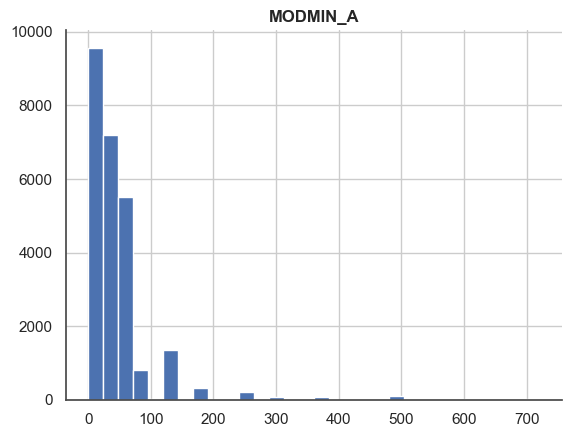

VIGMIN_A:
count    25328.000000
mean        20.587058
std         43.154780
min          0.000000
25%          0.000000
50%          0.000000
75%         30.000000
max        720.000000
Name: VIGMIN_A, dtype: float64


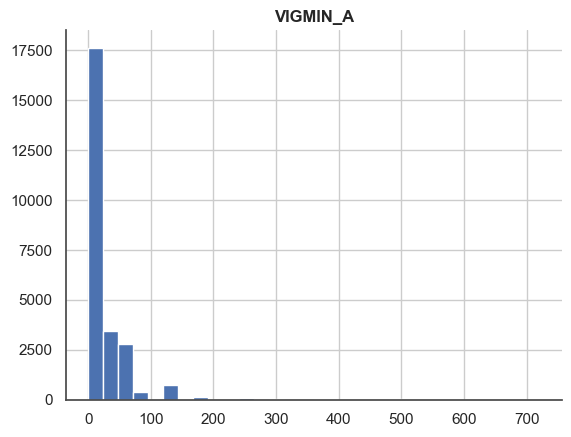

In [951]:
# Imputación de variables min cuando freq > 0 -> USAR X_train y no df_fe!!!!!

vars_imputar = ['MODMIN_A', 'VIGMIN_A']
for var in vars_imputar:
    print(f"{var}:\n{X_train[var].describe()}")
    X_train[var].hist(bins=30)
    plt.title(var)
    plt.show()



**Observación:**

Ambas variables tienen una distribución asimétrica, con una concentración mayor en 0. En el caso de `VIGMIN_A`, incluso la mediana=0. Debemos usar la mediana para imputar, por la forma de la distribución usar la media no tendría sentido. Tampoco tiene sentido eliminar las filas en las que la duración de actividad es 0, ya que sabemos que la frecuencia es > 0, lo que significa que son personas que respondieron que sí hacen actividades moderadas o vigorosas durante la semana, solo que no respondieron la duración por actividad por semana (respondieron No sé en la encuesta). 

Lo que necesitamos hacer es aislar a quienes respondieron 'No sé' en la duración, pero dijeron que sí hacían actividad moderada o vigorosa. Esas son las filas a imputar. Y la imputación a aplicar debería ser la mediana de las personas que sí dieron una duración a las actividades correspondientes.

In [952]:
for freq, dur in duracion_x_freq.items():
    print(f"Nulos en {dur}: X_train: {X_train[dur].isna().sum()} X_test: {X_test[dur].isna().sum()}")
    mascara_activos = X_train[freq] > 0
    mediana = X_train.loc[mascara_activos, dur].median()
    X_train[dur] = X_train[dur].fillna(mediana)
    X_test[dur] = X_test[dur].fillna(mediana)
    print(f"Nulos en {dur}: X_train: {X_train[dur].isna().sum()} X_test: {X_test[dur].isna().sum()}")



Nulos en MODMIN_A: X_train: 809 X_test: 204
Nulos en MODMIN_A: X_train: 0 X_test: 0
Nulos en VIGMIN_A: X_train: 775 X_test: 195
Nulos en VIGMIN_A: X_train: 0 X_test: 0


**Observación:**

Antes de definir el binning de las variables min, debemos calcular los totales de minutos semanales de actividad por tipo. Esto es relevante porque queremos aplicar los umbrales definidos en el paper de CDC/WHO de la bibliografía. Por esto, creamos nuevas variables con estos datos.

MODMIN_WEEKLY:
count    26103.000000
mean       178.414703
std        341.244127
min          0.000000
25%          0.000000
50%         90.000000
75%        210.000000
max      10080.000000
Name: MODMIN_WEEKLY, dtype: float64


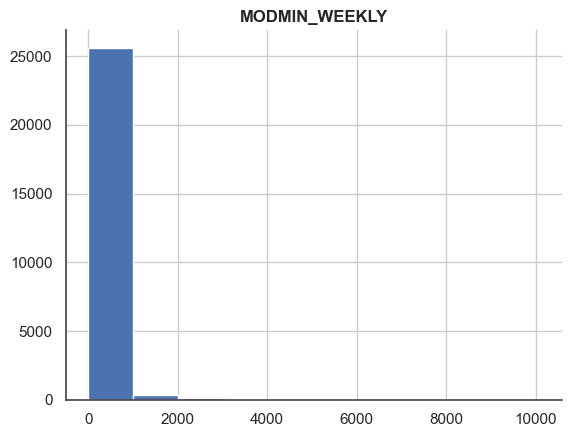

VIGMIN_WEEKLY:
count    26103.000000
mean        51.684940
std        172.869777
min          0.000000
25%          0.000000
50%          0.000000
75%         30.000000
max       6720.000000
Name: VIGMIN_WEEKLY, dtype: float64


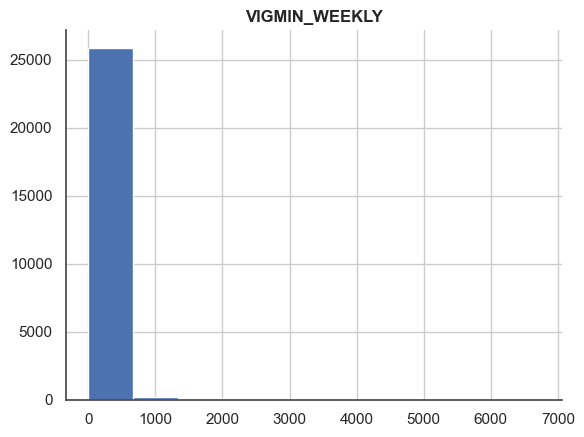

In [953]:
# Crear columnas de duración semanal
X_train['MODMIN_WEEKLY'] = X_train['MODMIN_A'] * X_train['MODFREQW_A']
X_train['VIGMIN_WEEKLY'] = X_train['VIGMIN_A'] * X_train['VIGFREQW_A']
X_test['MODMIN_WEEKLY'] = X_test['MODMIN_A'] * X_test['MODFREQW_A']
X_test['VIGMIN_WEEKLY'] = X_test['VIGMIN_A'] * X_test['VIGFREQW_A']

vars_dur_semanal = ['MODMIN_WEEKLY', 'VIGMIN_WEEKLY']
features = features + vars_dur_semanal
numeric_features = numeric_features + vars_dur_semanal

# Revisamos la distribución para decidir cómo aplicar el binning sugerido en los papers
for var in vars_dur_semanal:
    print(f"{var}:\n{X_train[var].describe()}")
    X_train[var].hist(bins=10)
    plt.title(var)
    plt.show()

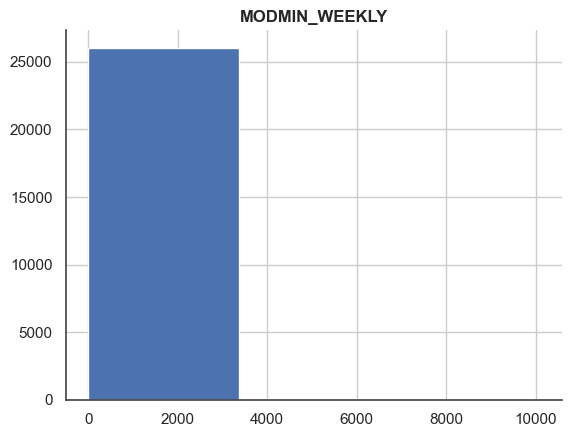

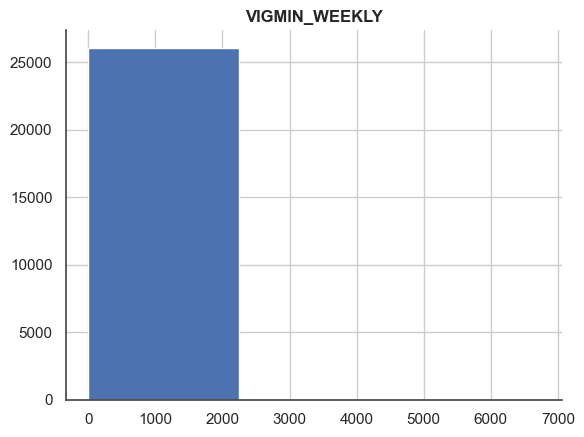

In [954]:
# Revisar opciones de binning para variables min
for var in vars_dur_semanal:
    X_train[var].hist(bins=3)
    plt.title(var)
    plt.show()


In [955]:
bins_act_moderada = [-0.1, 0, 149, 299, float('inf')]
labels_act_moderada = ['sin', 'insuficiente', 'minimo', 'supera']

bins_act_vigorosa = [-0.1, 0, 74, 149, float('inf')]
labels_act_vigorosa = ['sin', 'insuficiente', 'minimo', 'supera']

X_train['MOD_LEVEL'] = pd.cut(X_train['MODMIN_WEEKLY'], bins=bins_act_moderada, labels=labels_act_moderada)
X_train['VIG_LEVEL'] = pd.cut(X_train['VIGMIN_WEEKLY'], bins=bins_act_vigorosa, labels=labels_act_vigorosa)
X_test['MOD_LEVEL'] = pd.cut(X_test['MODMIN_WEEKLY'], bins=bins_act_moderada, labels=labels_act_moderada)
X_test['VIG_LEVEL'] = pd.cut(X_test['VIGMIN_WEEKLY'], bins=bins_act_vigorosa, labels=labels_act_vigorosa)

for var in ['MOD_LEVEL', 'VIG_LEVEL']:
    features.append(var)
    categorical_features.append(var)
    print(f"{X_train[var].value_counts()}")

MOD_LEVEL
insuficiente    8445
sin             8093
minimo          4785
supera          4780
Name: count, dtype: int64
VIG_LEVEL
sin             18636
supera           2875
insuficiente     2720
minimo           1872
Name: count, dtype: int64


#### Correlación de features con y


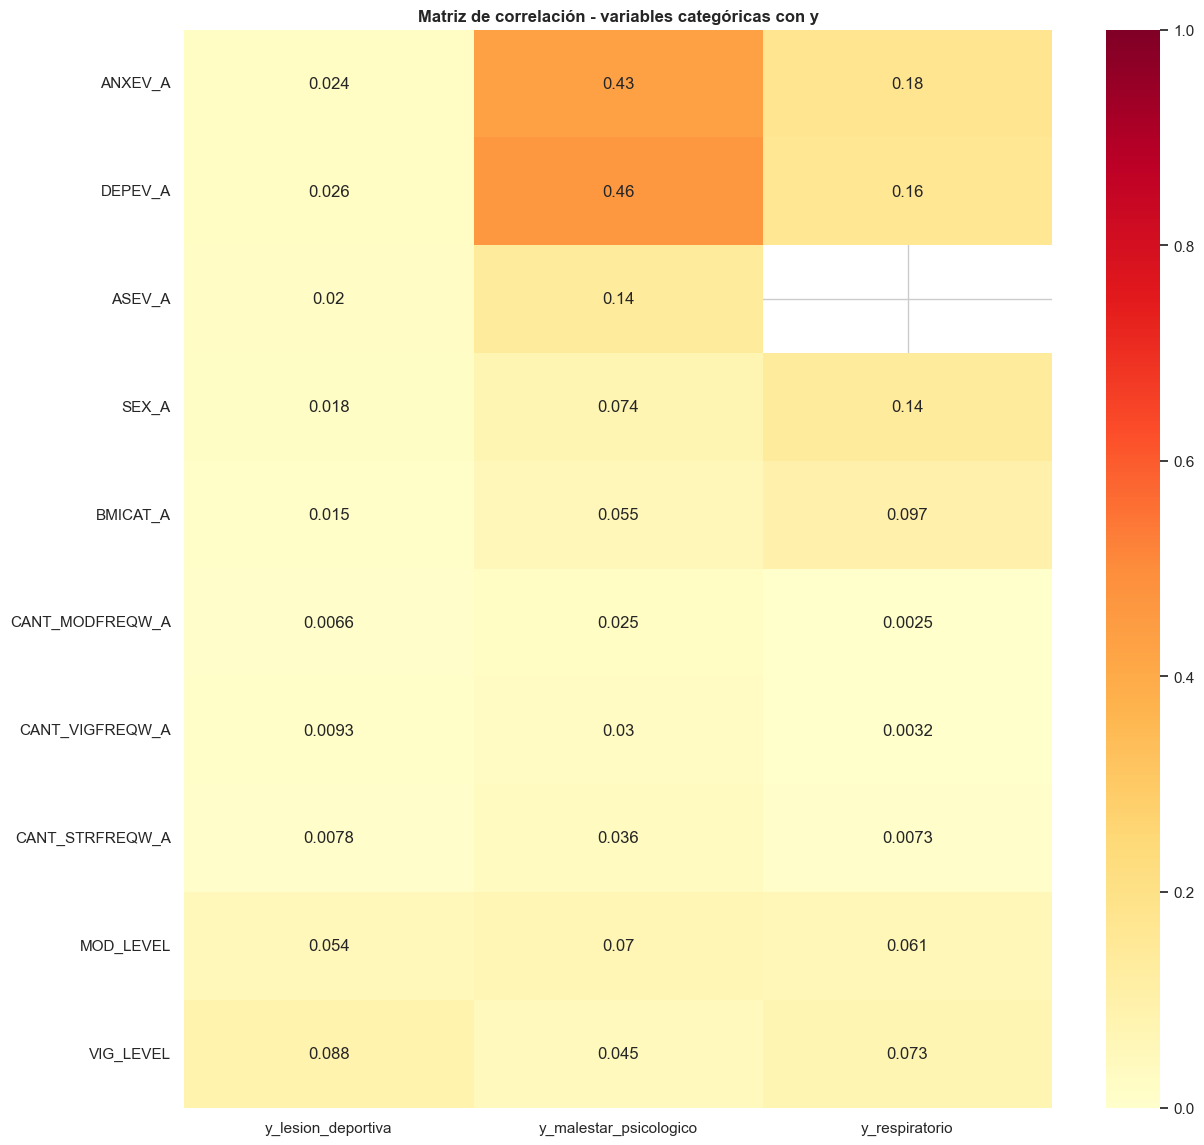

In [956]:

corr_matrix_cramers_y = pd.DataFrame(
    index=categorical_features, columns=variables_objetivo,
    dtype=float # para que procese NaNs
)
for col1 in categorical_features:
    for col2 in variables_objetivo:
        corr_matrix_cramers_y.loc[col1, col2] = cramers(X_train[col1], y_train[col2])
plt.figure(figsize = (14, 14))
sns.heatmap(
    corr_matrix_cramers_y,
    annot = True,
    vmin = 0,
    vmax = 1,
    cmap = "YlOrRd"
)
plt.title("Matriz de correlación - variables categóricas con y")
plt.show()

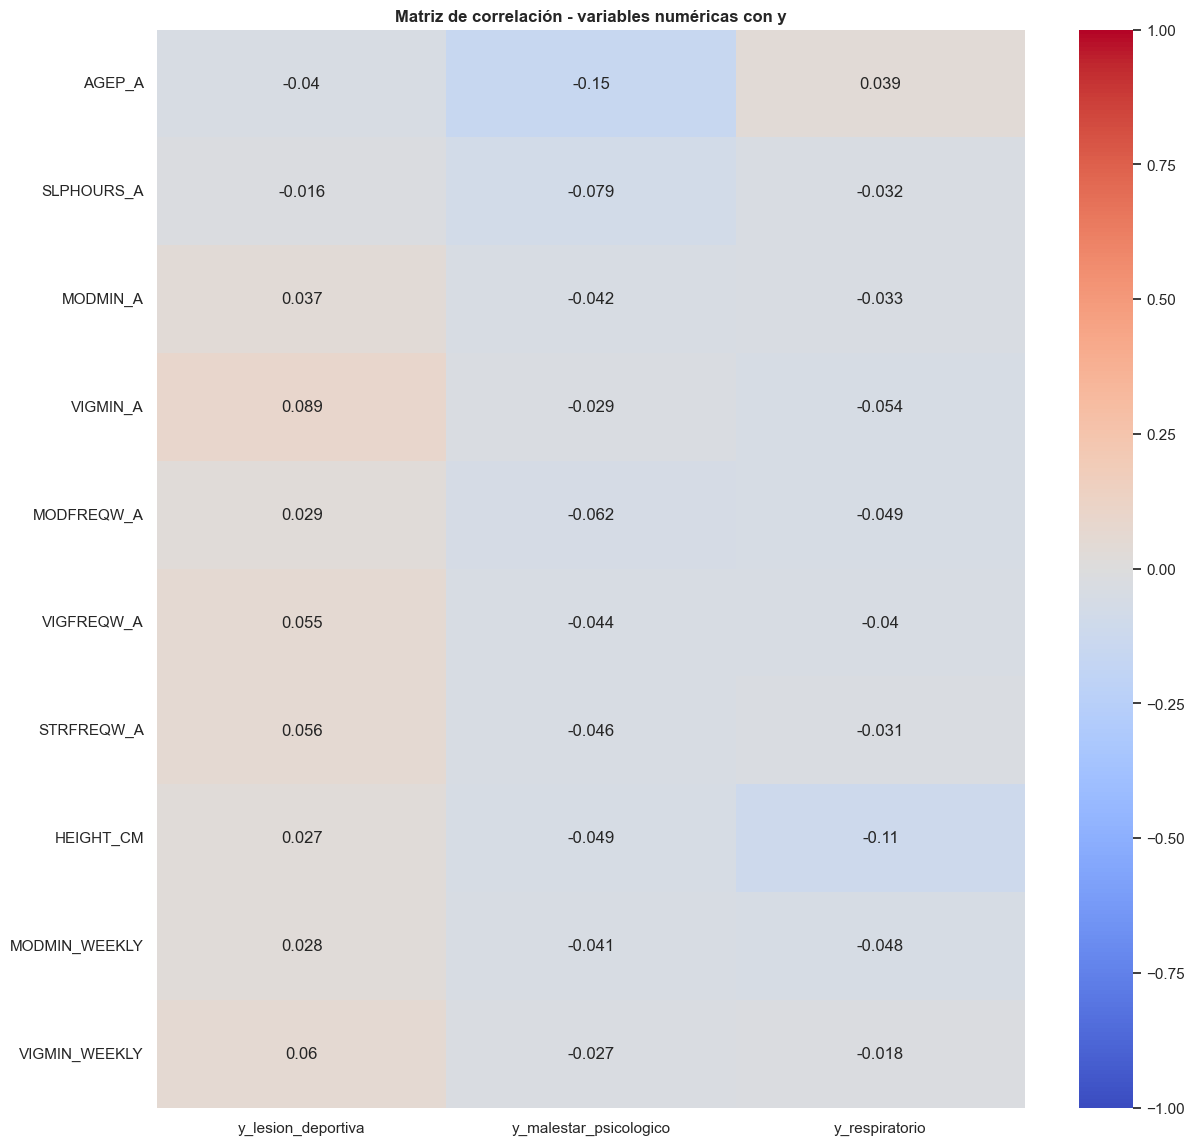

In [957]:
# Correlación numéricas con y

corr_matrix_pearson_y = pd.concat([X_train[numeric_features], y_train[variables_objetivo]], axis=1).corr(method='pearson').loc[numeric_features, variables_objetivo]
plt.figure(figsize = (14, 14))
sns.heatmap(
    corr_matrix_pearson_y,
    annot = True,
    vmin = -1,
    vmax = 1,
    cmap = "coolwarm"
)
plt.title("Matriz de correlación - variables numéricas con y")
plt.show()

## Módulo 3: Model Tuning

* Recordar eliminación de filas con variables objetivo en NaN para el modelado, sin borrarlas definitivamente del df a usar!!!
* Revisar, si al final de los modelos se escoge XGBoost, recordar que los árboles pueden modelar missings (SVM no)

### Modelos a probar

### Preprocesamiento

In [958]:
X_train[numeric_features + categorical_features].isna().sum()

AGEP_A               46
SLPHOURS_A          892
MODMIN_A              0
VIGMIN_A              0
MODFREQW_A            0
VIGFREQW_A            0
STRFREQW_A          768
HEIGHT_CM          1823
MODMIN_WEEKLY         0
VIGMIN_WEEKLY         0
ANXEV_A              36
DEPEV_A              35
ASEV_A               24
SEX_A                 4
BMICAT_A            475
CANT_MODFREQW_A       0
CANT_VIGFREQW_A       0
CANT_STRFREQW_A       0
MOD_LEVEL             0
VIG_LEVEL             0
dtype: int64

In [959]:
for var in variables_objetivo:
    print(f"Not NaNs en {var}: {y_train[var].notna().sum()}/{len(y_train)}")

Not NaNs en y_lesion_deportiva: 26103/26103
Not NaNs en y_malestar_psicologico: 25450/26103
Not NaNs en y_respiratorio: 3815/26103


In [960]:
X_train.columns



Index(['AGEP_A', 'SLPHOURS_A', 'MODMIN_A', 'VIGMIN_A', 'MODFREQW_A',
       'VIGFREQW_A', 'STRFREQW_A', 'ANXEV_A', 'DEPEV_A', 'ASEV_A', 'SEX_A',
       'BMICAT_A', 'CANT_MODFREQW_A', 'CANT_VIGFREQW_A', 'CANT_STRFREQW_A',
       'HEIGHT_CM', 'MODMIN_WEEKLY', 'VIGMIN_WEEKLY', 'MOD_LEVEL',
       'VIG_LEVEL'],
      dtype='object')

In [961]:
# ColumnTransformer

numeric_features


['AGEP_A',
 'SLPHOURS_A',
 'MODMIN_A',
 'VIGMIN_A',
 'MODFREQW_A',
 'VIGFREQW_A',
 'STRFREQW_A',
 'HEIGHT_CM',
 'MODMIN_WEEKLY',
 'VIGMIN_WEEKLY']

In [962]:

categorical_features


['ANXEV_A',
 'DEPEV_A',
 'ASEV_A',
 'SEX_A',
 'BMICAT_A',
 'CANT_MODFREQW_A',
 'CANT_VIGFREQW_A',
 'CANT_STRFREQW_A',
 'MOD_LEVEL',
 'VIG_LEVEL']

In [963]:
# Separamos las variables por tipo de transformer a usar: cat, ord, num standard o num outlier
num_std_features, num_outlier_features = [f for f in numeric_features if f not in vars_dur_semanal], vars_dur_semanal
cat_std_features = [f for f in categorical_features if f not in ['MOD_LEVEL', 'VIG_LEVEL']]
cat_ordinal_features = [f for f in categorical_features if f in ['MOD_LEVEL', 'VIG_LEVEL']]


In [964]:

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

robust_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('encoder', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))
])

ord_categories = ['sin', 'insuficiente', 'minimo', 'supera']
ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[ord_categories, ord_categories]))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_std_features), # numeric
    ('num_outlier', robust_transformer, num_outlier_features), # num outliers in activity duration features
    ('cat', categorical_transformer, cat_std_features), # categoric
    ('ord', ordinal_transformer, cat_ordinal_features) # ordinal cat
])

In [965]:
X_transformed = preprocessor.fit_transform(X_train)
print(X_transformed.shape)

(26103, 32)


In [966]:
# Crear una funcion para entrenar modelos y no tener que repetir codigo por todo lado :)

def train_model(modelo, param_grid, var_objetivo, tipo_var_objetivo, preprocessor, cv,
                    X_train, X_test, y_train, y_test):
    print(f"Prueba {var_objetivo} - {modelo.__class__.__name__} ...")
    
    # Filtrar los NaN en variable objetivo
    mascara_train = y_train[var_objetivo].notna()
    mascara_test = y_test[var_objetivo].notna()
    X_train_masked, y_train_masked =  X_train.loc[mascara_train], y_train.loc[mascara_train, var_objetivo]
    X_test_masked, y_test_masked = X_test.loc[mascara_test], y_test.loc[mascara_test, var_objetivo]

    # pipeline de entrenamiento con preprocessor
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', modelo)
    ])

    # scoring depende del tipo de var obj
    if tipo_var_objetivo == "ord":
        metrics = "f1_macro"
    else:
        metrics = "roc_auc"

    # Hacer un grid search para ir probando hiperparametros
    grid_model = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=metrics,
        verbose=3,
        n_jobs=-1
    )

    # Entrenar
    grid_model.fit(X_train_masked, y_train_masked)

    print(f"Best score {metrics}: {grid_model.best_score_:.4f}\nBest params: \n{grid_model.best_params_}")
    print(f"Best estimator: {grid_model.best_estimator_}")
    grid_model

    return grid_model


In [967]:
# Quiero intentar probar XGBoost, RandomForest, SVM, regresion logística? ... revisar las vars min weekly, log?

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)


In [968]:

modelos = [
    {
        'nombre': 'LogisticRegression',
        'modelo': LogisticRegression(max_iter=1000),
        'params': {
            'model__C': [0.01, 0.1, 1, 5, 10],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}, None] # balanceo de clases vs none
        }
    },
    {
        'nombre': 'XGBoost',
        'modelo': XGBoost.XGBClassifier(random_state=random_seed, eval_metric='logloss'),
        'params': {
            'model__max_depth': [3, 5, 10, None],
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.01, 0.1] 
        }
    },
    {
        'nombre': 'RandomForest',
        'modelo': RandomForestClassifier(random_state=random_seed),
        'params': {
            'model__max_depth': [3, 5, 10, None],
            'model__n_estimators': [100, 200, 300],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}, None] # balanceo de clases vs none
        }
    },
    {
        'nombre': 'RBF',
        'modelo': SVC(),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['rbf', 'lineal'],
            'model__class_weight': ['balanced', None] # balanceo de clases vs none
        }
    }
]

variables_objetivo_tuplas = [
    # ('y_lesion', 'ord'),
    ('y_lesion_deportiva', 'bin'),
    ('y_malestar_psicologico', 'ord'),
    ('y_respiratorio', 'bin')
]


In [969]:

# resultados = {}

# for var_obj, tipo in variables_objetivo_tuplas:
#     for model in modelos:
#         grid = train_model(model['modelo'], model['params'], var_obj, tipo, preprocessor, cv, X_train, X_test, y_train, y_test)
#         resultados[model['nombre'], var_obj] = grid

**Observación:** 

Inicialmente se ejecutó train_model para LogisticRegression, RandomForest, XGBoost y SVM con LinearSVC y RBF.
Muchos folds de SVM, en especial SVM lineal directo tardaban entre 20-180 minutos, por lo que se detuvo la ejecución,
para examinar los resultados hasta ese momento y decidir como continuar el model tuning.

Hasta este momento, los scores se ven así:

**Prueba y_lesion - LogisticRegression ...**

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best score f1_macro: 0.2708 
Best params:  {'model__C': 10, 'model__class_weight': 'balanced'}

**Prueba y_lesion - XGBClassifier ...** 

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best score f1_macro: 0.2377 Best params:  {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 300}

**y_lesion - RandomForestClassifier ...** 

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best score f1_macro: 0.2882 Best params:  {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__n_estimators': 300}

**Prueba y_lesion - SVC ...**

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best score f1_macro: 0.2950 Best params:  {'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}

**Prueba y_malestar_psicologico - LogisticRegression ...** 

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best score f1_macro: 0.4480 Best params:  {'model__C': 5, 'model__class_weight': 'balanced'}

**Prueba y_malestar_psicologico - XGBClassifier ...** 

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best score f1_macro: 0.4556 Best params:  {'model__learning_rate': 0.1, 'model__max_depth': None, 'model__n_estimators': 300}

**Prueba y_malestar_psicologico - RandomForestClassifier ...** 

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best score f1_macro: 0.4924 Best params:  {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__n_estimators': 200}

**Prueba y_malestar_psicologico - SVC ...**

Fitting 5 folds for each of 12 candidates, totalling 60 fits
STOPPED EXECUTION

In [970]:
# Separamos los modelos SVM en una variable distinta:

modelos_svm = [
    {
        'nombre': 'RBF',
        'modelo': SVC(),
        'params': {
            'model__C': [0.1, 1, 10, 50, 100],
            'model__gamma': ['scale', 'auto'],
            'model__kernel': ['rbf'],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}, None] # balanceo de clases vs none
        }
    },
    {
        'nombre': 'LinearSVC',
        'modelo': LinearSVC(),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}, None], # balanceo de clases vs none
            'model__dual': [False]
        }
    }
]

modelos_prin = [
    {
        'nombre': 'LogisticRegression',
        'modelo': LogisticRegression(max_iter=1000),
        'params': {
            'model__C': [0.01, 0.1, 1, 5, 10],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}, None] # balanceo de clases vs none
        }
    },
    {
        'nombre': 'XGBoost',
        'modelo': XGBoost.XGBClassifier(random_state=random_seed, eval_metric='logloss'),
        'params': {
            'model__max_depth': [3, 5, 10, None],
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.01, 0.1] 
        }
    },
    {
        'nombre': 'RandomForest',
        'modelo': RandomForestClassifier(random_state=random_seed),
        'params': {
            'model__max_depth': [3, 5, 10, None],
            'model__n_estimators': [100, 200, 300],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}, None] # balanceo de clases vs none
        }
    }
]

In [971]:
resultados_y_lesion_deportiva = {}

for model in modelos_prin:
    grid = train_model(model['modelo'], model['params'], 'y_lesion_deportiva', 'bin', preprocessor, cv, X_train, X_test, y_train, y_test)
    resultados_y_lesion_deportiva[model['nombre'], 'y_lesion_deportiva'] = grid

Prueba y_lesion_deportiva - LogisticRegression ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


[CV 3/5] END model__C=0.01, model__class_weight=balanced;, score=0.740 total time=   0.3s
[CV 1/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.657 total time=   0.3s
[CV 3/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.740 total time=   0.3s
[CV 5/5] END model__C=0.01, model__class_weight=balanced;, score=0.714 total time=   0.3s
[CV 1/5] END model__C=0.01, model__class_weight=balanced;, score=0.657 total time=   0.3s
[CV 2/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.718 total time=   0.3s
[CV 2/5] END model__C=0.01, model__class_weight=balanced;, score=0.720 total time=   0.3s
[CV 4/5] END model__C=0.01, model__class_weight=balanced;, score=0.677 total time=   0.3s
[CV 5/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.708 total time=   0.2s
[CV 4/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.675 total time=   0.2s
[CV 1/5] END model__C=0.01, model__class_weight={0: 1, 1: 25};, score=0.657

In [972]:
params_depor_svm = {
            'model__C': [0.1, 1, 10],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}], # balanceo de clases vs none
            'model__dual': [False]
        }
grid_depor_svm = train_model(LinearSVC(), params_depor_svm, 'y_lesion_deportiva', 'bin', preprocessor, cv, X_train, X_test, y_train, y_test)
resultados_y_lesion_deportiva['LinearSVC', 'y_lesion_deportiva'] = grid_depor_svm

Prueba y_lesion_deportiva - LinearSVC ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 3/5] END model__C=0.1, model__class_weight={0: 1, 1: 10}, model__dual=False;, score=0.741 total time=   0.3s
[CV 1/5] END model__C=0.1, model__class_weight={0: 1, 1: 10}, model__dual=False;, score=0.657 total time=   0.3s
[CV 4/5] END model__C=0.1, model__class_weight=balanced, model__dual=False;, score=0.674 total time=   0.3s
[CV 3/5] END model__C=0.1, model__class_weight=balanced, model__dual=False;, score=0.739 total time=   0.4s
[CV 2/5] END model__C=0.1, model__class_weight=balanced, model__dual=False;, score=0.718 total time=   0.4s
[CV 5/5] END model__C=0.1, model__class_weight=balanced, model__dual=False;, score=0.712 total time=   0.4s
[CV 1/5] END model__C=0.1, model__class_weight=balanced, model__dual=False;, score=0.655 total time=   0.4s
[CV 2/5] END model__C=0.1, model__class_weight={0: 1, 1: 10}, model__dual=False;, score=0.717 total time=   0.5s
[CV 4/5] END model

In [973]:
params_depor_rbf = {
            'model__C': [0.1, 1, 10, 50, 100],
            'model__gamma': ['scale', 'auto'],
            'model__kernel': ['rbf'],
            'model__class_weight': ['balanced', {0: 1, 1: 10}, {0: 1, 1: 25}, {0: 1, 1: 50}] # balanceo de clases vs none
        }
grid_depor_rbf = train_model(SVC(), params_depor_rbf, 'y_lesion_deportiva', 'bin', preprocessor, cv, X_train, X_test, y_train, y_test)
resultados_y_lesion_deportiva['RBF', 'y_lesion_deportiva'] = grid_depor_rbf

Prueba y_lesion_deportiva - SVC ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=rbf;, score=0.646 total time=  39.1s
[CV 2/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.685 total time=  39.9s
[CV 1/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.656 total time=  40.1s
[CV 4/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.697 total time=  40.5s
[CV 5/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.693 total time=  40.5s
[CV 3/5] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=rbf;, score=0.727 total time=  41.3s
[CV 3/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.738 total time=  44.7s
[CV 2/5]

In [974]:
print(f"y_lesion_deportiva grids:")
for (nombre, var_obj), grid in resultados_y_lesion_deportiva.items():
    print(f"{nombre:20s} best_score={grid.best_score_:.4f}  params={grid.best_params_}")

y_lesion_deportiva grids:
LogisticRegression   best_score=0.7015  params={'model__C': 0.01, 'model__class_weight': 'balanced'}
XGBoost              best_score=0.7066  params={'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}
RandomForest         best_score=0.7037  params={'model__class_weight': None, 'model__max_depth': 5, 'model__n_estimators': 300}
LinearSVC            best_score=0.7008  params={'model__C': 10, 'model__class_weight': {0: 1, 1: 10}, 'model__dual': False}
RBF                  best_score=0.6938  params={'model__C': 0.1, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'rbf'}


In [976]:
# resultados_y_lesion = {}

# for model in modelos_prin:
#     grid = train_model(model['modelo'], model['params'], 'y_lesion', 'ord', preprocessor, cv, X_train, X_test, y_train, y_test)
#     resultados_y_lesion[model['nombre'], 'y_lesion'] = grid

In [977]:
# for model in modelos_svm:
#     grid = train_model(model['modelo'], model['params'], 'y_lesion', 'ord', preprocessor, cv, X_train, X_test, y_train, y_test)
#     resultados_y_lesion[model['nombre'], 'y_lesion'] = grid

In [978]:
# for (nombre, var_obj), grid in resultados_y_lesion.items():
#     print(f"{nombre:20s} best_score={grid.best_score_:.4f}  params={grid.best_params_}")

In [979]:
# Vamos a correr los modelos principales para y_respiratorio que no corrió en la ejecución anterior

resultados_y_respiratorio = {}

for model in modelos_prin:
    grid = train_model(model['modelo'], model['params'], 'y_respiratorio', 'bin', preprocessor, cv, X_train, X_test, y_train, y_test)
    resultados_y_respiratorio[model['nombre'], 'y_respiratorio'] = grid

Prueba y_respiratorio - LogisticRegression ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 2/5] END model__C=0.01, model__class_weight=balanced;, score=0.655 total time=   0.1s
[CV 4/5] END model__C=0.01, model__class_weight=balanced;, score=0.657 total time=   0.1s
[CV 3/5] END model__C=0.01, model__class_weight=balanced;, score=0.638 total time=   0.1s
[CV 5/5] END model__C=0.01, model__class_weight=balanced;, score=0.643 total time=   0.1s
[CV 3/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.638 total time=   0.1s
[CV 1/5] END model__C=0.01, model__class_weight=balanced;, score=0.658 total time=   0.1s
[CV 1/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.658 total time=   0.1s
[CV 2/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.654 total time=   0.1s
[CV 4/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.660 total time=   0.1s
[CV 5/5] END model__C=0.01, model__class_weight={0: 1, 1: 10}

In [980]:
for model in modelos_svm:
    grid = train_model(model['modelo'], model['params'], 'y_respiratorio', 'bin', preprocessor, cv, X_train, X_test, y_train, y_test)
    resultados_y_respiratorio[model['nombre'], 'y_respiratorio'] = grid

Prueba y_respiratorio - SVC ...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 3/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.628 total time=   0.9s
[CV 5/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.642 total time=   0.9s
[CV 4/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.641 total time=   1.0s
[CV 3/5] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=rbf;, score=0.630 total time=   0.9s
[CV 2/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.663 total time=   1.1s
[CV 1/5] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=rbf;, score=0.639 total time=   1.0s
[CV 2/5] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=rbf;, score=0.665 total time=   1.0s
[CV 1/5] END 

In [982]:
print(f"y_respiratorio grids:")
for (nombre, var_obj), grid in resultados_y_respiratorio.items():
    print(f"{nombre:20s} best_score={grid.best_score_:.4f}  params={grid.best_params_}")

y_respiratorio grids:
LogisticRegression   best_score=0.6503  params={'model__C': 0.01, 'model__class_weight': {0: 1, 1: 10}}
XGBoost              best_score=0.6531  params={'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
RandomForest         best_score=0.6534  params={'model__class_weight': None, 'model__max_depth': 3, 'model__n_estimators': 300}
RBF                  best_score=0.6459  params={'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'rbf'}
LinearSVC            best_score=0.6482  params={'model__C': 0.1, 'model__class_weight': None, 'model__dual': False}


In [983]:
# Entrenamos los modelos svm para y_malestar_psicologico
resultados_y_malestar_psicologico = {}

for model in modelos_svm:
    grid = train_model(model['modelo'], model['params'], 'y_malestar_psicologico', 'ord', preprocessor, cv, X_train, X_test, y_train, y_test)
    resultados_y_malestar_psicologico[model['nombre'], 'y_malestar_psicologico'] = grid

Prueba y_malestar_psicologico - SVC ...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 2/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.416 total time= 1.0min
[CV 2/5] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=rbf;, score=0.420 total time= 1.0min
[CV 4/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.419 total time= 1.0min
[CV 3/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.436 total time= 1.0min
[CV 1/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.415 total time= 1.0min
[CV 5/5] END model__C=0.1, model__class_weight=balanced, model__gamma=scale, model__kernel=rbf;, score=0.417 total time= 1.0min
[CV 3/5] END model__C=0.1, model__class_weight=balanced, model__gamma=auto, model__kernel=rbf;, score=0.449 total time= 1.0min
[CV 

In [984]:
for model in modelos_prin:
    grid = train_model(model['modelo'], model['params'], 'y_malestar_psicologico', 'ord', preprocessor, cv, X_train, X_test, y_train, y_test)
    resultados_y_malestar_psicologico[model['nombre'], 'y_malestar_psicologico'] = grid

Prueba y_malestar_psicologico - LogisticRegression ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 2/5] END model__C=0.01, model__class_weight=balanced;, score=0.439 total time=   0.5s
[CV 3/5] END model__C=0.01, model__class_weight=balanced;, score=0.446 total time=   0.5s
[CV 4/5] END model__C=0.01, model__class_weight=balanced;, score=0.449 total time=   0.5s
[CV 5/5] END model__C=0.01, model__class_weight=balanced;, score=0.450 total time=   0.6s
[CV 3/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.304 total time=   0.6s
[CV 1/5] END model__C=0.01, model__class_weight=balanced;, score=0.460 total time=   0.6s
[CV 1/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.307 total time=   0.7s
[CV 2/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.308 total time=   0.8s
[CV 4/5] END model__C=0.01, model__class_weight={0: 1, 1: 10};, score=0.309 total time=   0.7s
[CV 1/5] END model__C=0.01, model__class_weight={0: 1

In [986]:
print(f"y_malestar_psicologico grids:")
for (nombre, var_obj), grid in resultados_y_malestar_psicologico.items():
    print(f"{nombre:20s} best_score={grid.best_score_:.4f}  params={grid.best_params_}")

y_malestar_psicologico grids:
RBF                  best_score=0.4772  params={'model__C': 50, 'model__class_weight': 'balanced', 'model__gamma': 'auto', 'model__kernel': 'rbf'}
LinearSVC            best_score=0.4857  params={'model__C': 0.1, 'model__class_weight': 'balanced', 'model__dual': False}
LogisticRegression   best_score=0.4497  params={'model__C': 10, 'model__class_weight': 'balanced'}
XGBoost              best_score=0.4711  params={'model__learning_rate': 0.1, 'model__max_depth': None, 'model__n_estimators': 200}
RandomForest         best_score=0.4986  params={'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__n_estimators': 300}


#### Feature importance

In [398]:
resultados_y_respiratorio[('XGBoost', 'y_respiratorio')]

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('num_outlier', ...), ...]"


In [989]:
importance_config = [
    ('y_lesion_deportiva', resultados_y_lesion_deportiva[('XGBoost', 'y_lesion_deportiva')].best_estimator_, 'roc_auc'),
    # RF fue el mejor en el training inicial
    ('y_malestar_psicologico', resultados_y_malestar_psicologico[('RandomForest', 'y_malestar_psicologico')].best_estimator_, 'f1_macro'), 
    # XGBoost fue el mejor en el training inicial
    ('y_respiratorio', resultados_y_respiratorio[('RandomForest', 'y_respiratorio')].best_estimator_, 'roc_auc') 
]

print(f"Feature importance para el mejor modelo por variable objetivo:")
for var_obj, modelo, metrica in importance_config:
    mascara_nan = y_test[var_obj].notna()
    X_test_masked = X_test.loc[mascara_nan]
    y_test_masked = y_test.loc[mascara_nan, var_obj]

    resultado = permutation_importance(
        modelo, X_test_masked, y_test_masked, scoring=metrica, n_repeats=10, random_state=random_seed, n_jobs=-1
    )
    orden_importancia = pd.Series(resultado.importances_mean, index=X_test_masked.columns).sort_values(ascending=False)
    print(f"{var_obj} - {modelo.named_steps['model'].__class__.__name__} - {metrica}:\n{orden_importancia}\n")





Feature importance para el mejor modelo por variable objetivo:
y_lesion_deportiva - XGBClassifier - roc_auc:
VIGMIN_A           0.046411
STRFREQW_A         0.038827
DEPEV_A            0.015191
MODMIN_A           0.009016
VIGMIN_WEEKLY      0.007536
AGEP_A             0.002955
HEIGHT_CM          0.002141
MODMIN_WEEKLY      0.000934
ANXEV_A            0.000757
ASEV_A             0.000509
CANT_VIGFREQW_A    0.000000
MOD_LEVEL          0.000000
CANT_STRFREQW_A    0.000000
SEX_A              0.000000
CANT_MODFREQW_A    0.000000
BMICAT_A           0.000000
VIG_LEVEL          0.000000
VIGFREQW_A        -0.000069
MODFREQW_A        -0.000091
SLPHOURS_A        -0.000657
dtype: float64

y_malestar_psicologico - RandomForestClassifier - f1_macro:
DEPEV_A            0.069613
ANXEV_A            0.028398
CANT_STRFREQW_A    0.000096
CANT_VIGFREQW_A    0.000017
CANT_MODFREQW_A    0.000012
SEX_A             -0.001839
SLPHOURS_A        -0.001992
AGEP_A            -0.002636
VIGFREQW_A        -0.002742
VIG

**Observación:**

Sobre y_respiratorio: recordemos que habíamos eliminado ya los registros de personas no asmáticas, obviamente ASEV_A como variable va a dar igual, porque todos son asmáticos, tienen el mismo valor.

Habría que ver qué sucedería si incluímos a los no asmáticos de nuevo y cómo podríamos manejarlo.

Llama la atención aún así que para y_respiratorio, padecer de ansiedad lidera y creo que tiene algo de sentido, ya que algunos síntomas de la ansiedad suelen ser respiratorios. Me llama la atención que tengamos variables de actividad positivas pero no todas, acá hay un poco de relación entre el hacer ejercicio y tener crisis respiratoria, pero aún más si se padece de ansiedad.

Sobre y_malestar_psicológico: 

Preocupa mucho, los datos nos estan diciendo que da igual con o sin ejercicio, da igual el nivel de actividad física, no hay cambio en los malestares psicológicos. Será cuestión de mejorar los hiperparámetros en tuning? No hay ninguna variable relacionada con actividad física que haya sido señalada con un nivel positivo de importancia. Casi podríamos estar diciendo que depende únicamente de los diagnósticos de ansiedad y depresión, pero los estudios no respaldan esa afirmación. Será que es mejor enfocarnos sólo en depresión, y que al tener ambos está sucediendo algo con la predicción basada en actividad física?

### Tuneado de Modelos

#### Tuenado de XGBoost y_lesion_deportiva

Inicial:

* XGBoost              best_score=0.7066  params={'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}
* RandomForest         best_score=0.7037  params={'model__class_weight': None, 'model__max_depth': 5, 'model__n_estimators': 300}
* LogisticRegression   best_score=0.7015  params={'model__C': 0.01, 'model__class_weight': 'balanced'}


In [ ]:
modelo_lesion = XGBoost.XGBClassifier(
    random_state=random_seed
)

params_grid_lesion_v1 = {
    'model__max_depth': [1, 2, 3],
    'model__n_estimators': [50, 100, 150],
    'model__learning_rate': [0.005, 0.01, 0.05],
    'model__scale_pos_weight': [1, 25, 50], ##
    'model__subsample': [0.5, 1.0],
    'model__colsample_bytree': [0.5, 1.0] ##
}

grid_lesion_v1 = train_model(
    modelo_lesion,
    params_grid_lesion_v1,
    'y_lesion_deportiva',
    'bin',
    preprocessor,
    cv,
    X_train,
    X_test,
    y_train,
    y_test
)

Prueba y_lesion_deportiva - XGBClassifier ...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV 1/5] END model__colsample_bytree=0.5, model__learning_rate=0.005, model__max_depth=1, model__n_estimators=50, model__scale_pos_weight=1, model__subsample=1.0;, score=0.671 total time=   0.4s
[CV 2/5] END model__colsample_bytree=0.5, model__learning_rate=0.005, model__max_depth=1, model__n_estimators=50, model__scale_pos_weight=1, model__subsample=1.0;, score=0.695 total time=   0.3s
[CV 5/5] END model__colsample_bytree=0.5, model__learning_rate=0.005, model__max_depth=1, model__n_estimators=50, model__scale_pos_weight=1, model__subsample=0.5;, score=0.672 total time=   0.3s
[CV 1/5] END model__colsample_bytree=0.5, model__learning_rate=0.005, model__max_depth=1, model__n_estimators=50, model__scale_pos_weight=1, model__subsample=0.5;, score=0.663 total time=   0.3s
[CV 4/5] END model__colsample_bytree=0.5, model__learning_rate=0.005, model__max_depth=1, model__n_estimators=

In [ ]:
grid_lesion_v1.best_estimator_


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num_outlier', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
params_grid_lesion_v2 = {
    'model__max_depth': [3],
    'model__n_estimators': [100],
    'model__learning_rate': [0.001, 0.003, 0.005],
    'model__scale_pos_weight': [1],
    'model__subsample': [0.2, 0.3, 0.4, 0.5],
    'model__colsample_bytree': [1.0],
}

grid_lesion_v2 = train_model(
    modelo_lesion,
    params_grid_lesion_v2,
    'y_lesion_deportiva',
    'bin',
    preprocessor,
    cv,
    X_train,
    X_test,
    y_train,
    y_test
)

Prueba y_lesion_deportiva - XGBClassifier ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 5/5] END model__colsample_bytree=1.0, model__learning_rate=0.001, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.2;, score=0.715 total time=   0.3s
[CV 2/5] END model__colsample_bytree=1.0, model__learning_rate=0.001, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.2;, score=0.717 total time=   0.3s
[CV 3/5] END model__colsample_bytree=1.0, model__learning_rate=0.001, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.2;, score=0.752 total time=   0.4s
[CV 2/5] END model__colsample_bytree=1.0, model__learning_rate=0.001, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.3;, score=0.718 total time=   0.4s
[CV 1/5] END model__colsample_bytree=1.0, model__learning_rate=0.001, model__max_depth=3, model__n_estimators

In [1000]:
grid_lesion_v2.best_estimator_

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num_outlier', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Tuneado de RandomForest y_malestar_psicologico


In [1001]:
# BEST: RandomForest         best_score=0.4986  params={'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__n_estimators': 300}

modelo_mal_psicologico = RandomForestClassifier(
    random_state=random_seed
)

params_mal_psicologico_v1 = {
    'model__max_depth': [10, 12, 14, 16],
    'model__n_estimators': [250, 300, 350],
    'model__class_weight': ['balanced'],
    'model__criterion': ['gini', 'entropy'],
    'model__max_features': [5, 8, 'sqrt'],
    'model__min_samples_leaf': [1, 2, 3, 4]

}

grid_mal_psicologico_v1 = train_model(
    modelo_mal_psicologico,
    params_mal_psicologico_v1,
    'y_malestar_psicologico',
    'ord',
    preprocessor,
    cv,
    X_train,
    X_test,
    y_train,
    y_test
)

Prueba y_malestar_psicologico - RandomForestClassifier ...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[CV 3/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=10, model__max_features=5, model__min_samples_leaf=1, model__n_estimators=250;, score=0.505 total time=  10.6s
[CV 1/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=10, model__max_features=5, model__min_samples_leaf=1, model__n_estimators=250;, score=0.503 total time=  11.1s
[CV 4/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=10, model__max_features=5, model__min_samples_leaf=1, model__n_estimators=250;, score=0.496 total time=  10.8s
[CV 5/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=10, model__max_features=5, model__min_samples_leaf=1, model__n_estimators=250;, score=0.496 total time=  11.3s
[CV 2/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=10, model__max_fea

In [1002]:
# Best score f1_macro: 0.5234
# Best params: 
# {'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 16, 'model__max_features': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}

params_mal_psicologico_v2 = {
    'model__max_depth': [16, 18, 20],
    'model__n_estimators': [300],
    'model__class_weight': ['balanced'],
    'model__criterion': ['gini'],
    'model__max_features': [8, 9, 10],
    'model__min_samples_leaf': [3]

}

grid_mal_psicologico_v2 = train_model(
    modelo_mal_psicologico,
    params_mal_psicologico_v2,
    'y_malestar_psicologico',
    'ord',
    preprocessor,
    cv,
    X_train,
    X_test,
    y_train,
    y_test
)

Prueba y_malestar_psicologico - RandomForestClassifier ...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 3/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=8, model__min_samples_leaf=3, model__n_estimators=300;, score=0.541 total time=   7.7s
[CV 5/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=8, model__min_samples_leaf=3, model__n_estimators=300;, score=0.509 total time=   7.8s
[CV 2/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=8, model__min_samples_leaf=3, model__n_estimators=300;, score=0.521 total time=   7.8s
[CV 4/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_features=8, model__min_samples_leaf=3, model__n_estimators=300;, score=0.521 total time=   7.8s
[CV 1/5] END model__class_weight=balanced, model__criterion=gini, model__max_depth=16, model__max_feature

In [1003]:
grid_mal_psicologico_v2.best_estimator_


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num_outlier', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1004]:
print(f"RandomForest y_malestar_psicologico\nBest score {grid_mal_psicologico_v2.best_score_:.4f}\n{grid_mal_psicologico_v2.best_params_}")

RandomForest y_malestar_psicologico
Best score 0.5238
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 16, 'model__max_features': 9, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}


#### Tuneado de RandomForest para y_respiratorio

* best_score=0.6534  
* params={'model__class_weight': None, 'model__max_depth': 3, 'model__n_estimators': 300}

In [ ]:
modelo_respiratorio = RandomForestClassifier(
    random_state=random_seed
)

params_respiratorio_v1 = {
    'model__max_depth': [2, 3, 4, 5],
    'model__n_estimators': [200, 300, 400],
    'model__min_samples_leaf': [1, 2, 4, 6],
    'model__max_features': [5, 7, 9, 'sqrt'],
    'model__class_weight': ['balanced', None],
    'model__criterion': ['gini', 'entropy']
}

grid_respiratorio_v1 = train_model(
    modelo_respiratorio,
    params_respiratorio_v1,
    'y_respiratorio',
    'bin',
    preprocessor,
    cv,
    X_train,
    X_test,
    y_train,
    y_test
)

Prueba y_respiratorio - RandomForestClassifier ...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits


In [524]:
print(f"XGBoost y_respiratorio\nBest score {grid_xg_v2.best_score_:.4f}\n{grid_xg_v2.best_params_}")

XGBoost y_respiratorio
Best score 0.6548
{'model__colsample_bytree': 0.5, 'model__learning_rate': 0.05, 'model__max_depth': 1, 'model__n_estimators': 300, 'model__scale_pos_weight': np.float64(2.8296593186372747), 'model__subsample': 0.5}


In [408]:
# Matrices de confusión


In [361]:
# grid_lesion

## Módulo 4: Evaluación

3 targets, uno por dominio
combinados en 1 target general de riesgo

In [ ]:
# Tuning de modelos



### Métricas

In [ ]:
# Función para boxplotear estabilidad de los modelos y matriz de confusion

def plot_model()


#### Matrices de Confusión

In [148]:

pred_lesion = grid_lesion.predict(X_test.loc[y_test['y_lesion'].notna()])
print(confusion_matrix(y_test.loc[y_test['y_lesion'].notna(), 'y_lesion'], pred_lesion))

[[2728  899  752  764]
 [ 203   94   94   80]
 [  99   54   88   67]
 [ 162   71  111  134]]


#### F1 Score y ROC AUC

### Comparación